In [54]:
import importlib
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import db_config

from db_config import get_database_url, get_database_render_url
from sqlalchemy import create_engine

In [3]:
pd.set_option('display.float_format', '{:.3f}'.format)

In [4]:
engine_local = create_engine(get_database_url(), pool_pre_ping=True)
df = pd.read_sql(
    "SELECT * FROM public.pollen_by_date_time",
    engine_local
)

df.head()

,fdate,ftime,camps_point_id,analysis_time,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
0,2026-07-22,05:00:00,11,2026-07-22,0.000,0.000,8.087,3.876,0.000,0.000,11.963
1,2026-07-22,23:00:00,15,2026-07-22,0.000,0.000,16.679,5.421,0.000,0.000,22.100
2,2026-07-22,23:00:00,14,2026-07-22,0.000,0.000,15.864,7.356,0.000,0.000,23.221
3,2026-07-22,23:00:00,13,2026-07-22,0.000,0.000,18.556,8.011,0.000,0.000,26.567
4,2026-07-22,23:00:00,12,2026-07-22,0.000,0.000,20.844,4.792,0.000,0.000,25.636


In [5]:
df['fdate'] = pd.to_datetime(df['fdate'], format='%Y-%m-%d')
df['ftime'] = pd.to_datetime(df['ftime'], format='%H:%M:%S').dt.time
df['analysis_time'] = pd.to_datetime(df['analysis_time'], format='%Y-%m-%d')
df.head(24)

,fdate,ftime,camps_point_id,analysis_time,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
0,2026-07-22,05:00:00,11,2026-07-22,0.000,0.000,8.087,3.876,0.000,0.000,11.963
1,2026-07-22,23:00:00,15,2026-07-22,0.000,0.000,16.679,5.421,0.000,0.000,22.100
2,2026-07-22,23:00:00,14,2026-07-22,0.000,0.000,15.864,7.356,0.000,0.000,23.221
3,2026-07-22,23:00:00,13,2026-07-22,0.000,0.000,18.556,8.011,0.000,0.000,26.567
4,2026-07-22,23:00:00,12,2026-07-22,0.000,0.000,20.844,4.792,0.000,0.000,25.636
5,2026-07-22,23:00:00,11,2026-07-22,0.000,0.000,23.864,2.292,0.000,0.000,26.156
6,2026-07-22,23:00:00,10,2026-07-22,0.000,0.000,20.056,9.618,0.000,0.000,29.674
7,2026-07-22,23:00:00,9,2026-07-22,0.000,0.000,16.759,13.110,0.000,0.000,29.869
8,2026-07-22,23:00:00,8,2026-07-22,0.000,0.000,16.799,13.837,0.000,0.000,30.637
9,2026-07-22,23:00:00,7,2026-07-22,0.000,0.000,26.215,10.723,0.000,0.000,36.938


In [6]:
df.dtypes

fdate             datetime64[s]
ftime                    object
camps_point_id            int64
analysis_time     datetime64[s]
alder_pollen            float64
birch_pollen            float64
grass_pollen            float64
mugwort_pollen          float64
olive_pollen            float64
ragweed_pollen          float64
pollen_total            float64
dtype: object

In [7]:
df_grouped = df.groupby(['fdate', 'camps_point_id'])[
    ['alder_pollen', 'birch_pollen', 'grass_pollen', 'mugwort_pollen', 'olive_pollen', 'ragweed_pollen', 'pollen_total']
].mean()
df_grouped.tail(20)

alder_pollen  birch_pollen  grass_pollen  \
fdate      camps_point_id                                             
2026-07-21 11                     0.000         0.000        10.161   
           12                     0.000         0.000         9.318   
           13                     0.000         0.000         8.660   
           14                     0.000         0.000         8.398   
           15                     0.000         0.000         8.637   
2026-07-22 1                      0.000         0.000        12.615   
           2                      0.000         0.000        12.738   
           3                      0.000         0.000        12.644   
           4                      0.000         0.000        12.806   
           5                      0.000         0.000        14.048   
           6                      0.000         0.000        14.850   
           7                      0.000         0.000        13.519   
           8                      0.000         0.000        10.819   
           9                      0.000         0.000        10.651   
           10                     0.000         0.000        11.927   
           11                     0.000         0.000        16.042   
           12                     0.000         0.000        13.859   
           13                     0.000         0.000        13.591   
           14                     0.000         0.000        12.659   
           15                     0.000         0.000        12.901   

                           mugwort_pollen  olive_pollen  ragweed_pollen  \
fdate      camps_point_id                                                 
2026-07-21 11                       1.416         0.000           0.000   
           12                       2.068         0.000           0.000   
           13                       2.590         0.000           0.000   
           14                       2.634         0.000           0.000   
           15                       2.089         0.000           0.000   
2026-07-22 1                        4.016         0.000           0.000   
           2                        3.990         0.000           0.000   
           3                        4.329         0.000           0.000   
           4                        4.637         0.000           0.000   
           5                        4.031         0.000           0.000   
           6                        3.810         0.000           0.000   
           7                        5.091         0.000           0.000   
           8                        7.219         0.000           0.000   
           9                        6.466         0.000           0.000   
           10                       4.980         0.000           0.000   
           11                       2.624         0.000           0.000   
           12                       3.615         0.000           0.000   
           13                       4.622         0.000           0.000   
           14                       4.516         0.000           0.000   
           15                       3.904         0.000           0.000   

                           pollen_total  
fdate      camps_point_id                
2026-07-21 11                    11.577  
           12                    11.387  
           13                    11.250  
           14                    11.032  
           15                    10.726  
2026-07-22 1                     16.631  
           2                     16.728  
           3                     16.974  
           4                     17.443  
           5                     18.079  
           6                     18.660  
           7                     18.610  
           8                     18.038  
           9                     17.117  
           10                    16.908  
           11                    18.667  
           12                    17.473  
           13  

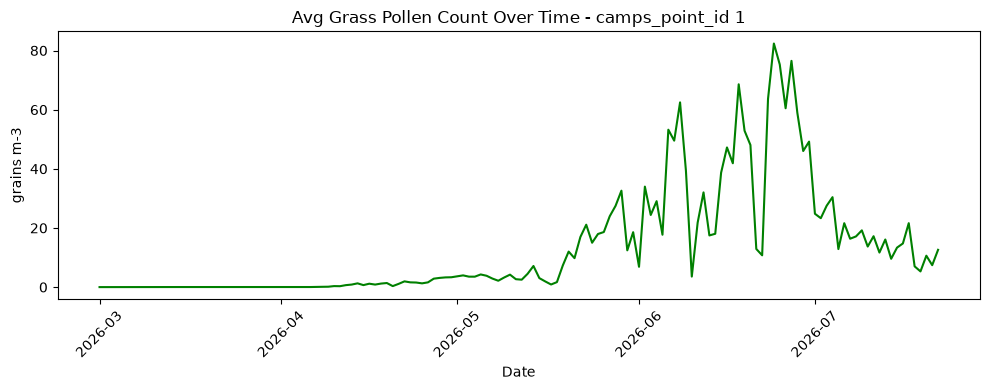

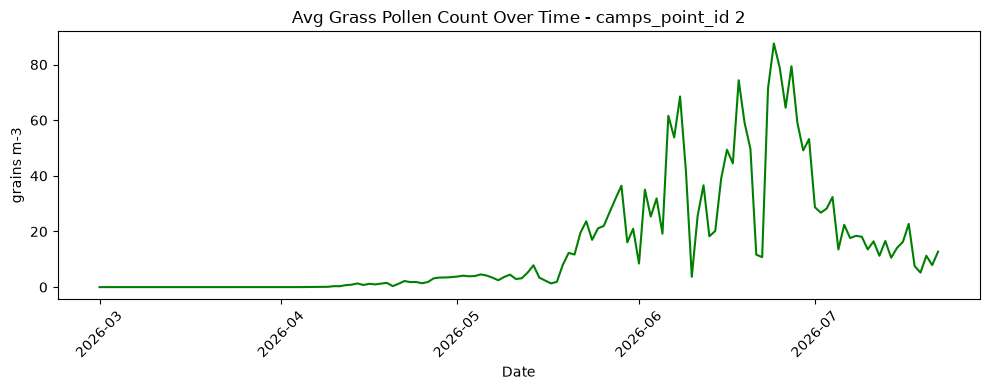

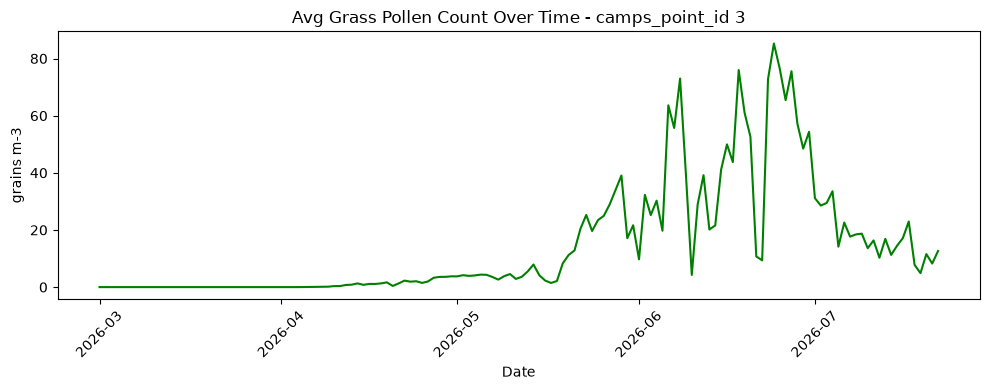

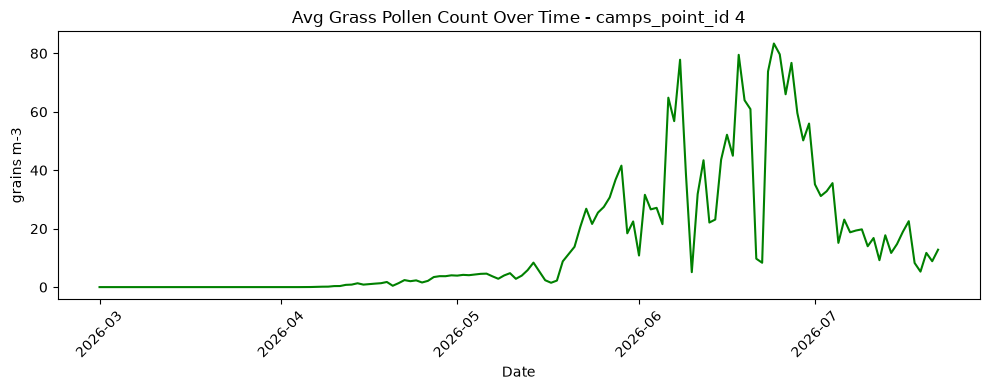

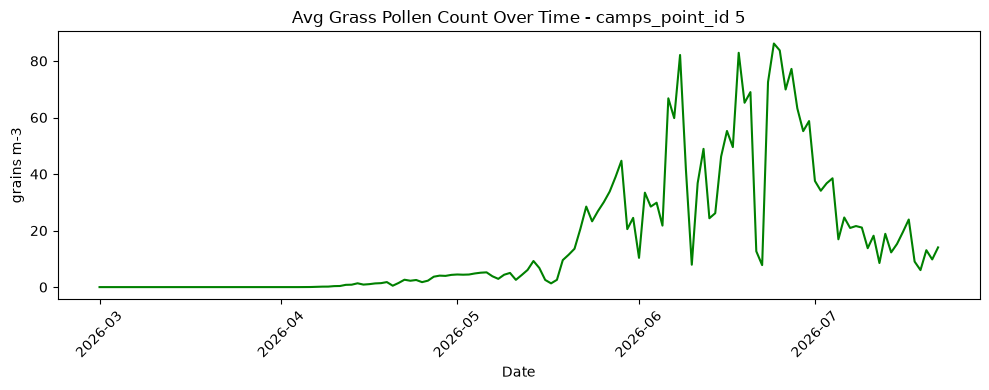

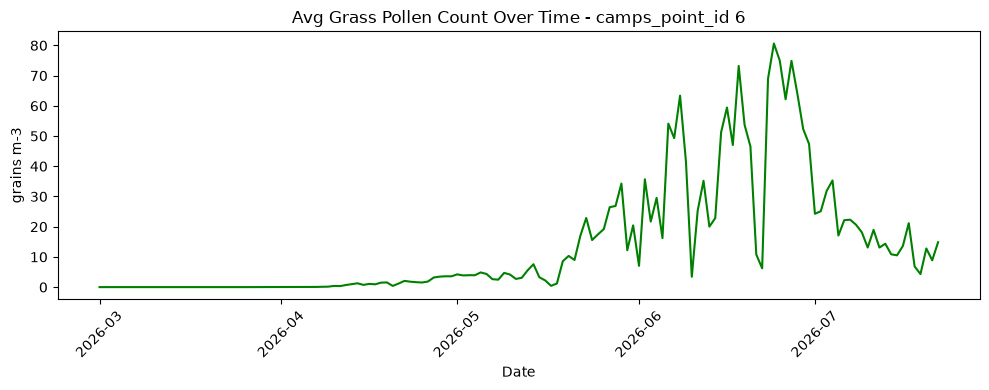

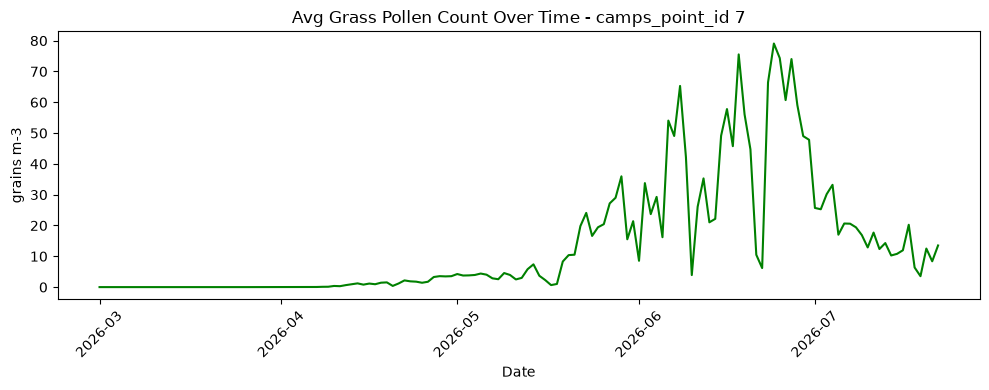

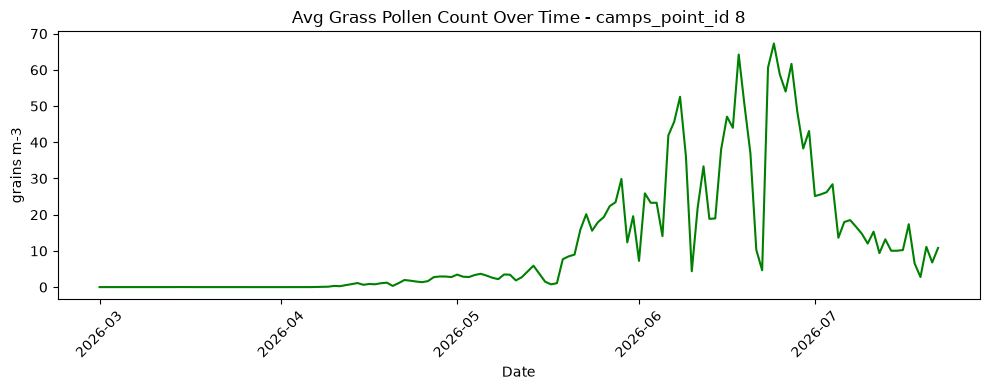

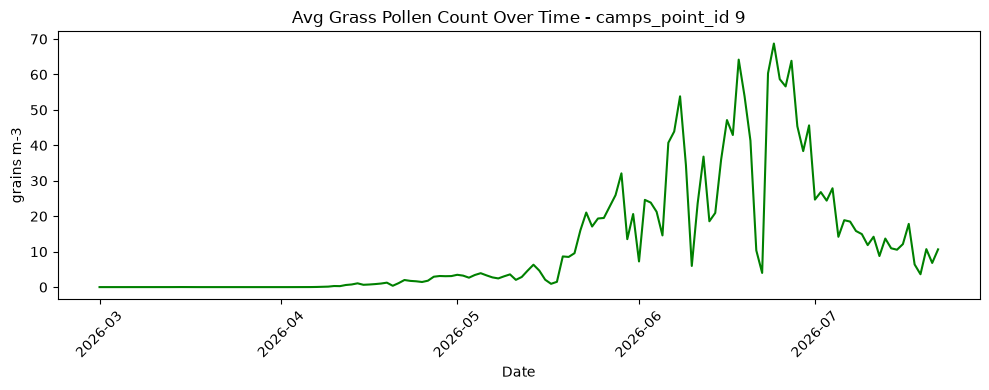

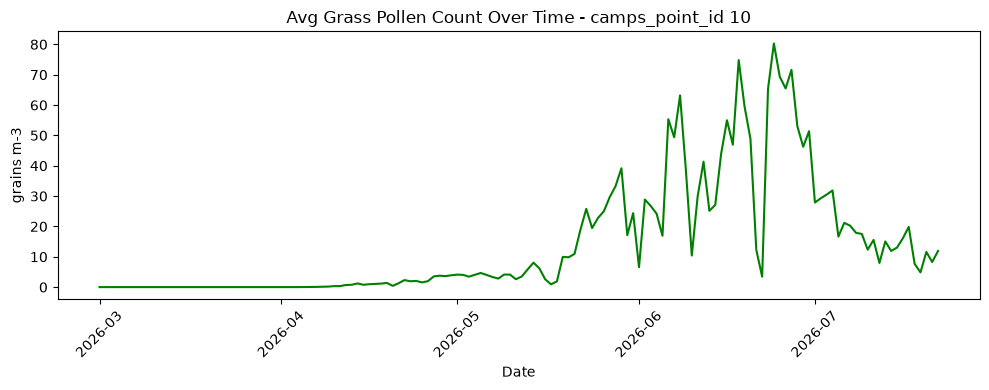

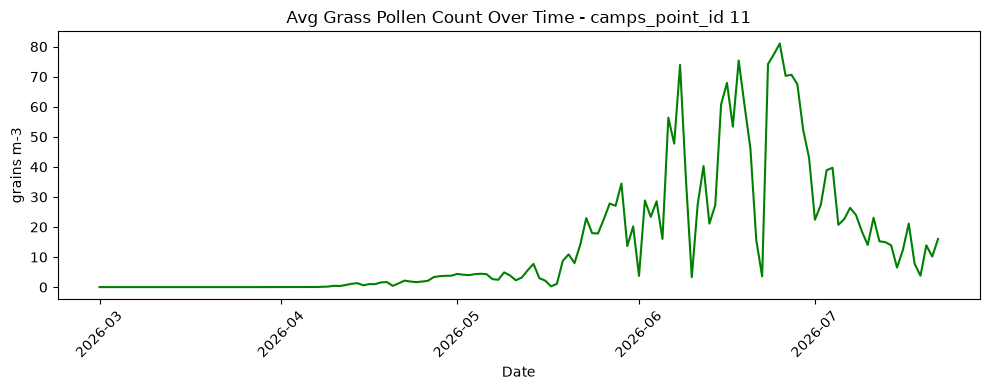

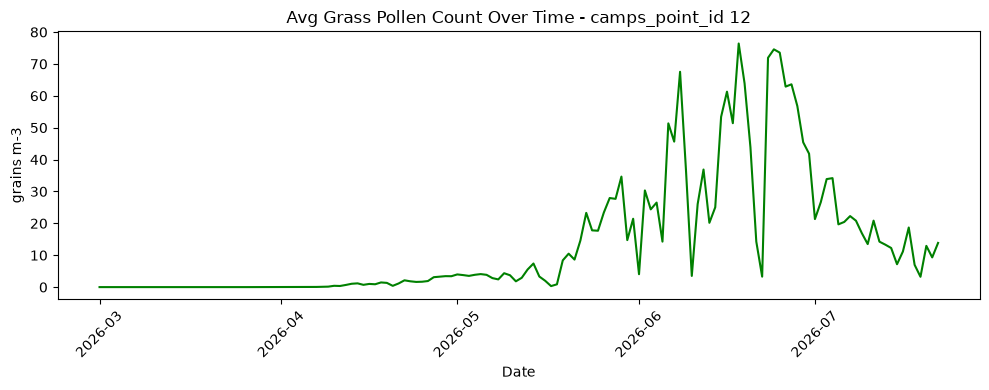

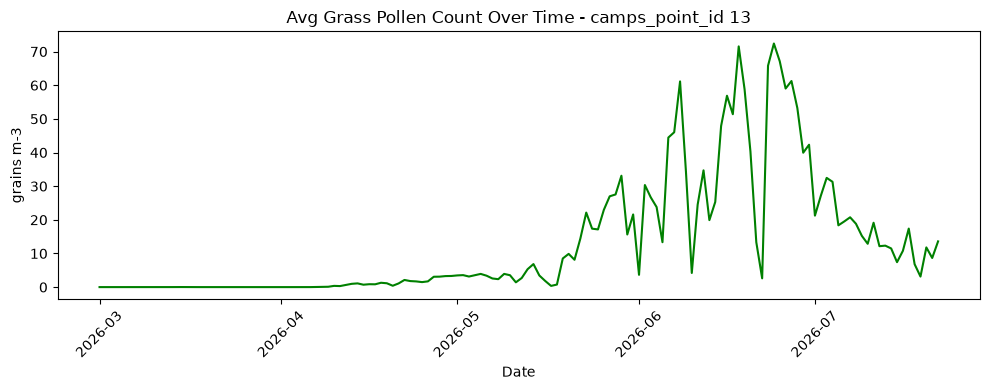

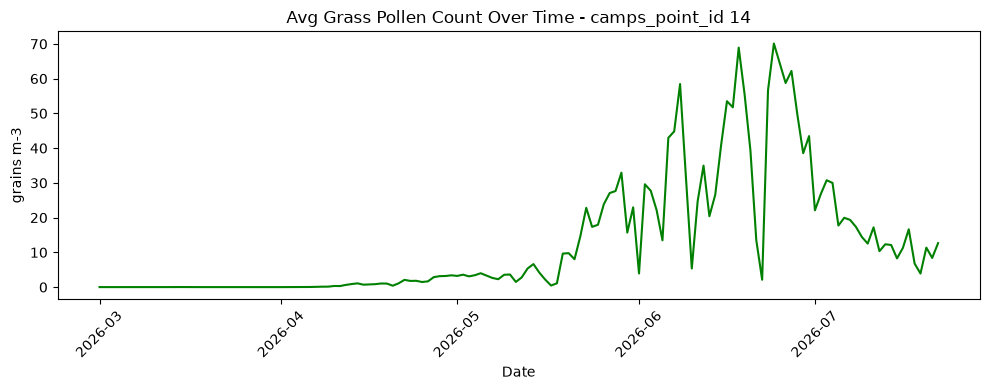

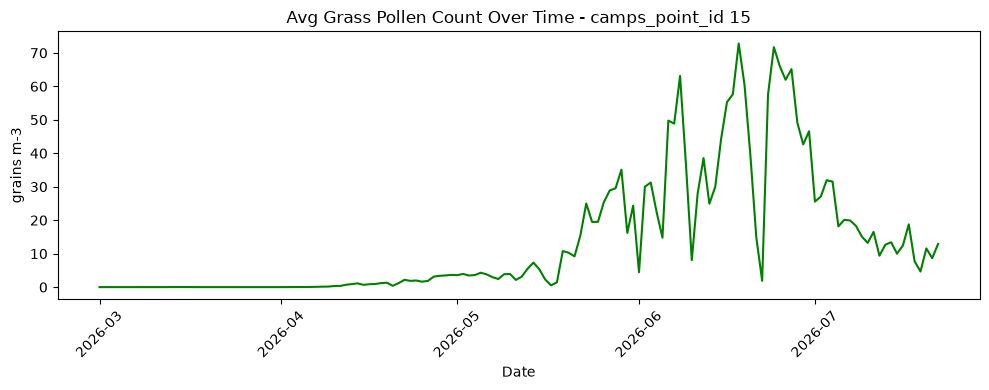

In [8]:
%matplotlib inline

site_ids = sorted(pd.to_numeric(df['camps_point_id'], errors='coerce').dropna().astype(int).unique())

for site_id in site_ids:
    site_series = (
        df_grouped.xs(site_id, level='camps_point_id')['grass_pollen']
        .sort_index()
    )
    plt.figure(figsize=(10, 4))
    plt.plot(site_series.index, site_series.values, color='g')
    plt.title(f"Avg Grass Pollen Count Over Time - camps_point_id {site_id}")
    plt.xlabel("Date")
    plt.xticks(rotation=45)
    plt.ylabel("grains m-3")
    plt.tight_layout()
    plt.show()

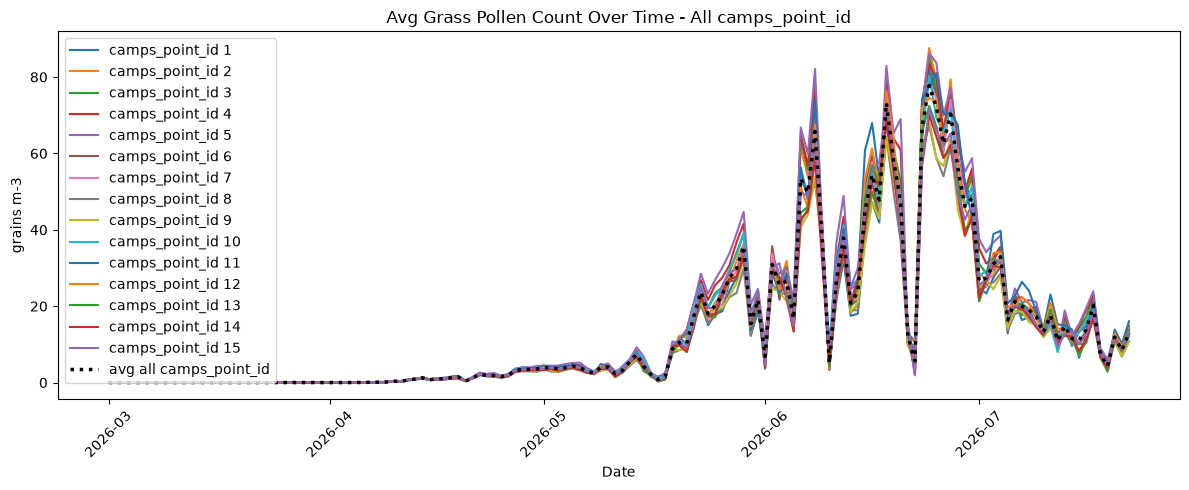

In [9]:
%matplotlib inline

plt.figure(figsize=(12, 5))

overall_avg = (
    df_grouped.groupby(level='fdate')['grass_pollen']
    .mean()
    .sort_index()
)

for site_id in site_ids:
    site_series = (
        df_grouped.xs(site_id, level='camps_point_id')['grass_pollen']
        .sort_index()
    )
    plt.plot(
        site_series.index,
        site_series.values,
        label=f'camps_point_id {site_id}',
        zorder=1
    )

plt.plot(
    overall_avg.index,
    overall_avg.values,
    label='avg all camps_point_id',
    linewidth=2.5,
    color='black',
    linestyle=':',
    zorder=2
)

plt.title('Avg Grass Pollen Count Over Time - All camps_point_id')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.ylabel('grains m-3')
plt.legend(loc='upper left', bbox_to_anchor=(0.0, 1.0))
plt.tight_layout()
plt.show()

In [10]:
df_grouped_time = (
    df.groupby(['fdate', 'ftime'], as_index=False)[
        ['alder_pollen', 'birch_pollen', 'grass_pollen', 'mugwort_pollen', 'olive_pollen', 'ragweed_pollen', 'pollen_total']
    ].mean()
)
df_grouped_time.tail(10)


,fdate,ftime,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
3446,2026-07-22,14:00:00,0.000,0.000,9.901,4.402,0.000,0.000,14.303
3447,2026-07-22,15:00:00,0.000,0.000,11.277,4.560,0.000,0.000,15.837
3448,2026-07-22,16:00:00,0.000,0.000,13.889,4.828,0.000,0.000,18.717
3449,2026-07-22,17:00:00,0.000,0.000,16.345,5.156,0.000,0.000,21.501
3450,2026-07-22,18:00:00,0.000,0.000,18.755,5.325,0.000,0.000,24.080
3451,2026-07-22,19:00:00,0.000,0.000,21.419,6.455,0.000,0.000,27.874
3452,2026-07-22,20:00:00,0.000,0.000,22.904,8.238,0.000,0.000,31.142
3453,2026-07-22,21:00:00,0.000,0.000,22.467,9.012,0.000,0.000,31.478
3454,2026-07-22,22:00:00,0.000,0.000,22.113,9.048,0.000,0.000,31.161
3455,2026-07-22,23:00:00,0.000,0.000,19.774,7.643,0.000,0.000,27.417


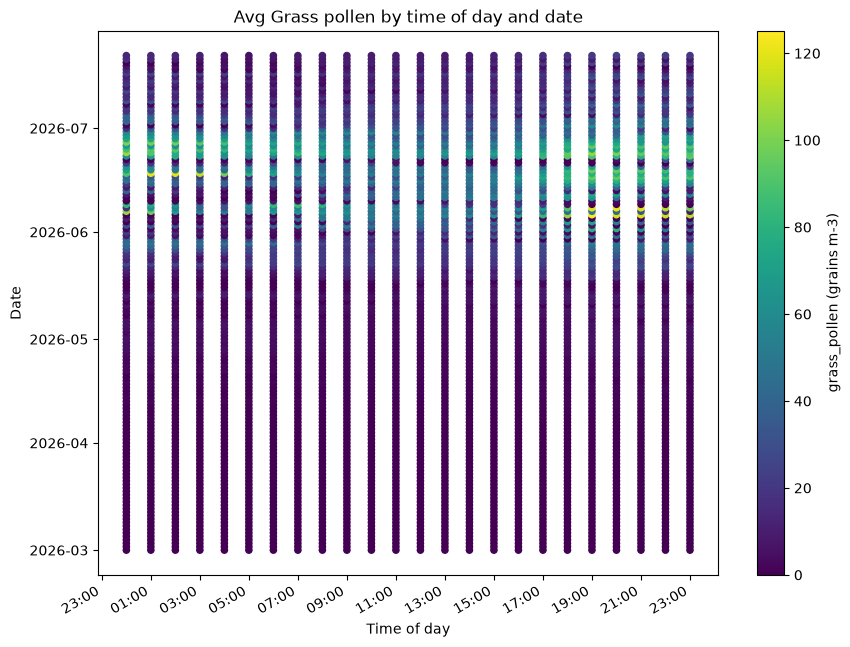

In [11]:
# Scatter plot: x = ftime (time of day), y = fdate (date), color = grass_pollen

ftimes = pd.to_datetime(df_grouped_time['ftime'].astype(str), format='%H:%M:%S', errors='coerce')
fdates = df_grouped_time['fdate']

plt.figure(figsize=(10, 8))
sc = plt.scatter(ftimes, fdates, c=df_grouped_time['grass_pollen'], cmap='viridis', s=20)
plt.colorbar(sc, label='grass_pollen (grains m-3)')
plt.xlabel('Time of day')
plt.ylabel('Date')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.gcf().autofmt_xdate()
plt.title(f'Avg Grass pollen by time of day and date')
plt.show()


In [12]:
engine_render = create_engine(get_database_render_url(), pool_pre_ping=True)
df_synop = pd.read_sql(
    """SELECT * FROM public.synop_data
    ORDER BY date DESC, measurement_hour ASC """,
    engine_render
)

df_synop.head()

,station_id,date,measurement_hour,date_add,date_update,station_name,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure
0,12566,2026-07-24,0,2026-07-24 01:00:33.824920,2026-07-24 01:00:33.822620,Kraków,13.500,5.000,260,88.700,0.500,1014.100
1,12566,2026-07-24,1,2026-07-24 02:00:51.113161,2026-07-24 02:00:51.110367,Kraków,13.300,5.000,270,88.100,0.500,1014.300
2,12566,2026-07-24,2,2026-07-24 03:00:23.705160,2026-07-24 03:00:23.701072,Kraków,13.200,4.000,260,88.100,0.500,1014.400
3,12566,2026-07-24,3,2026-07-24 04:00:46.110254,2026-07-24 04:00:46.106834,Kraków,13.000,5.000,280,88.100,0.500,1014.600
4,12566,2026-07-24,4,2026-07-24 05:00:26.790782,2026-07-24 05:00:26.790574,Kraków,12.900,4.000,260,85.700,0.500,1015.200


In [13]:
df_synop.dtypes

station_id                    int64
date                         object
measurement_hour              int64
date_add             datetime64[us]
date_update          datetime64[us]
station_name                    str
temperature                 float64
wind_speed                  float64
wind_direction                int64
relative_humidity           float64
rainfall_sum                float64
pressure                    float64
dtype: object

In [14]:
df_synop['date'] = pd.to_datetime(df_synop['date'], format='%Y-%m-%d')
df_synop['measurement_hour_dt'] = df_synop['date'] + pd.to_timedelta(df_synop['measurement_hour'], unit='h')
df_synop['measurement_hour'] = df_synop['measurement_hour_dt'].dt.time

df_synop['date_N_h_ahead'] = df_synop['measurement_hour_dt'] + pd.Timedelta(hours=12)

In [15]:
df_synop.head(5)

,station_id,date,measurement_hour,date_add,date_update,station_name,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,measurement_hour_dt,date_N_h_ahead
0,12566,2026-07-24,00:00:00,2026-07-24 01:00:33.824920,2026-07-24 01:00:33.822620,Kraków,13.500,5.000,260,88.700,0.500,1014.100,2026-07-24 00:00:00,2026-07-24 12:00:00
1,12566,2026-07-24,01:00:00,2026-07-24 02:00:51.113161,2026-07-24 02:00:51.110367,Kraków,13.300,5.000,270,88.100,0.500,1014.300,2026-07-24 01:00:00,2026-07-24 13:00:00
2,12566,2026-07-24,02:00:00,2026-07-24 03:00:23.705160,2026-07-24 03:00:23.701072,Kraków,13.200,4.000,260,88.100,0.500,1014.400,2026-07-24 02:00:00,2026-07-24 14:00:00
3,12566,2026-07-24,03:00:00,2026-07-24 04:00:46.110254,2026-07-24 04:00:46.106834,Kraków,13.000,5.000,280,88.100,0.500,1014.600,2026-07-24 03:00:00,2026-07-24 15:00:00
4,12566,2026-07-24,04:00:00,2026-07-24 05:00:26.790782,2026-07-24 05:00:26.790574,Kraków,12.900,4.000,260,85.700,0.500,1015.200,2026-07-24 04:00:00,2026-07-24 16:00:00


In [16]:
df_synop_filtered = df_synop[['date', 'date_N_h_ahead', 'measurement_hour', 'measurement_hour_dt', 'temperature', 'wind_speed', 'wind_direction', 'relative_humidity', 'rainfall_sum', 'pressure']].copy()
df_synop_filtered.head(24)

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure
0,2026-07-24,2026-07-24 12:00:00,00:00:00,2026-07-24 00:00:00,13.500,5.000,260,88.700,0.500,1014.100
1,2026-07-24,2026-07-24 13:00:00,01:00:00,2026-07-24 01:00:00,13.300,5.000,270,88.100,0.500,1014.300
2,2026-07-24,2026-07-24 14:00:00,02:00:00,2026-07-24 02:00:00,13.200,4.000,260,88.100,0.500,1014.400
3,2026-07-24,2026-07-24 15:00:00,03:00:00,2026-07-24 03:00:00,13.000,5.000,280,88.100,0.500,1014.600
4,2026-07-24,2026-07-24 16:00:00,04:00:00,2026-07-24 04:00:00,12.900,4.000,260,85.700,0.500,1015.200
5,2026-07-24,2026-07-24 17:00:00,05:00:00,2026-07-24 05:00:00,12.900,3.000,240,86.900,0.500,1015.400
6,2026-07-24,2026-07-24 18:00:00,06:00:00,2026-07-24 06:00:00,14.000,4.000,260,83.500,16.700,1015.500
7,2026-07-24,2026-07-24 19:00:00,07:00:00,2026-07-24 07:00:00,14.800,6.000,270,75.600,16.700,1015.600
8,2026-07-24,2026-07-24 20:00:00,08:00:00,2026-07-24 08:00:00,15.600,7.000,270,72.700,16.700,1015.200
9,2026-07-24,2026-07-24 21:00:00,09:00:00,2026-07-24 09:00:00,15.900,6.000,280,69.400,16.700,1015.200


In [17]:
df_synop_filtered['date_date_ahead'] = df_synop_filtered['date_N_h_ahead'].dt.date.copy()
df_synop_filtered['time_date_ahead'] = df_synop_filtered['date_N_h_ahead'].dt.time.copy()
df_synop_filtered['date_date_ahead'] = pd.to_datetime(df_synop_filtered['date_date_ahead'], format='%Y-%m-%d')
df_synop_filtered.head(24)

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead
0,2026-07-24,2026-07-24 12:00:00,00:00:00,2026-07-24 00:00:00,13.500,5.000,260,88.700,0.500,1014.100,2026-07-24,12:00:00
1,2026-07-24,2026-07-24 13:00:00,01:00:00,2026-07-24 01:00:00,13.300,5.000,270,88.100,0.500,1014.300,2026-07-24,13:00:00
2,2026-07-24,2026-07-24 14:00:00,02:00:00,2026-07-24 02:00:00,13.200,4.000,260,88.100,0.500,1014.400,2026-07-24,14:00:00
3,2026-07-24,2026-07-24 15:00:00,03:00:00,2026-07-24 03:00:00,13.000,5.000,280,88.100,0.500,1014.600,2026-07-24,15:00:00
4,2026-07-24,2026-07-24 16:00:00,04:00:00,2026-07-24 04:00:00,12.900,4.000,260,85.700,0.500,1015.200,2026-07-24,16:00:00
5,2026-07-24,2026-07-24 17:00:00,05:00:00,2026-07-24 05:00:00,12.900,3.000,240,86.900,0.500,1015.400,2026-07-24,17:00:00
6,2026-07-24,2026-07-24 18:00:00,06:00:00,2026-07-24 06:00:00,14.000,4.000,260,83.500,16.700,1015.500,2026-07-24,18:00:00
7,2026-07-24,2026-07-24 19:00:00,07:00:00,2026-07-24 07:00:00,14.800,6.000,270,75.600,16.700,1015.600,2026-07-24,19:00:00
8,2026-07-24,2026-07-24 20:00:00,08:00:00,2026-07-24 08:00:00,15.600,7.000,270,72.700,16.700,1015.200,2026-07-24,20:00:00
9,2026-07-24,2026-07-24 21:00:00,09:00:00,2026-07-24 09:00:00,15.900,6.000,280,69.400,16.700,1015.200,2026-07-24,21:00:00


In [18]:
df_synop_mean_by_date = df_synop_filtered.groupby('date', as_index=False)[[ 'temperature', 'wind_speed', 'wind_direction', 'relative_humidity', 'rainfall_sum', 'pressure']].mean()
df_synop_mean_by_date.tail()

,date,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure
129,2026-07-20,17.238,4.250,249.583,64.429,7.975,1017.654
130,2026-07-21,15.833,4.917,250.833,71.275,2.525,1018.800
131,2026-07-22,17.283,2.500,234.167,60.483,0.075,1017.071
132,2026-07-23,14.679,4.167,243.333,83.562,0.400,1013.288
133,2026-07-24,14.169,4.769,266.923,83.177,9.223,1015.108


In [19]:
df_merged = df_synop_filtered.merge(
    df_grouped_time[['fdate', 'ftime', 'grass_pollen']].rename(columns={'fdate': 'date', 'ftime': 'measurement_hour'}),
    on=['date', 'measurement_hour'],
    how='left'
)
df_merged.head(24)

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen
0,2026-07-24,2026-07-24 12:00:00,00:00:00,2026-07-24 00:00:00,13.500,5.000,260,88.700,0.500,1014.100,2026-07-24,12:00:00,NaN
1,2026-07-24,2026-07-24 13:00:00,01:00:00,2026-07-24 01:00:00,13.300,5.000,270,88.100,0.500,1014.300,2026-07-24,13:00:00,NaN
2,2026-07-24,2026-07-24 14:00:00,02:00:00,2026-07-24 02:00:00,13.200,4.000,260,88.100,0.500,1014.400,2026-07-24,14:00:00,NaN
3,2026-07-24,2026-07-24 15:00:00,03:00:00,2026-07-24 03:00:00,13.000,5.000,280,88.100,0.500,1014.600,2026-07-24,15:00:00,NaN
4,2026-07-24,2026-07-24 16:00:00,04:00:00,2026-07-24 04:00:00,12.900,4.000,260,85.700,0.500,1015.200,2026-07-24,16:00:00,NaN
5,2026-07-24,2026-07-24 17:00:00,05:00:00,2026-07-24 05:00:00,12.900,3.000,240,86.900,0.500,1015.400,2026-07-24,17:00:00,NaN
6,2026-07-24,2026-07-24 18:00:00,06:00:00,2026-07-24 06:00:00,14.000,4.000,260,83.500,16.700,1015.500,2026-07-24,18:00:00,NaN
7,2026-07-24,2026-07-24 19:00:00,07:00:00,2026-07-24 07:00:00,14.800,6.000,270,75.600,16.700,1015.600,2026-07-24,19:00:00,NaN
8,2026-07-24,2026-07-24 20:00:00,08:00:00,2026-07-24 08:00:00,15.600,7.000,270,72.700,16.700,1015.200,2026-07-24,20:00:00,NaN
9,2026-07-24,2026-07-24 21:00:00,09:00:00,2026-07-24 09:00:00,15.900,6.000,280,69.400,16.700,1015.200,2026-07-24,21:00:00,NaN


In [20]:
df_merged_mean_temperature_by_date = df_merged.merge(
    df_synop_mean_by_date[['date', 'temperature']].rename(columns={'temperature': 'avg_day_temperature'}),
    on=['date'],
    how='left'
)
df_merged_mean_temperature_by_date.head()

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature
0,2026-07-24,2026-07-24 12:00:00,00:00:00,2026-07-24 00:00:00,13.500,5.000,260,88.700,0.500,1014.100,2026-07-24,12:00:00,NaN,14.169
1,2026-07-24,2026-07-24 13:00:00,01:00:00,2026-07-24 01:00:00,13.300,5.000,270,88.100,0.500,1014.300,2026-07-24,13:00:00,NaN,14.169
2,2026-07-24,2026-07-24 14:00:00,02:00:00,2026-07-24 02:00:00,13.200,4.000,260,88.100,0.500,1014.400,2026-07-24,14:00:00,NaN,14.169
3,2026-07-24,2026-07-24 15:00:00,03:00:00,2026-07-24 03:00:00,13.000,5.000,280,88.100,0.500,1014.600,2026-07-24,15:00:00,NaN,14.169
4,2026-07-24,2026-07-24 16:00:00,04:00:00,2026-07-24 04:00:00,12.900,4.000,260,85.700,0.500,1015.200,2026-07-24,16:00:00,NaN,14.169


In [21]:
# 5 AM to 9 PM = day, 10 PM to 4 AM = night
df_merged_mean_temperature_by_date['day_night'] = df_merged_mean_temperature_by_date['measurement_hour_dt'].apply(
    lambda x: 'day' if 5 <= x.hour <= 21 else 'night'
)

# Calculate average temperature per day/night period and map it back to each row
avg_day_temp = (
    df_merged_mean_temperature_by_date[df_merged_mean_temperature_by_date['day_night'] == 'day']
    .groupby('date')['temperature']
    .mean()
    .rename('avg_day_light_temperature')
)

avg_night_temp = (
    df_merged_mean_temperature_by_date[df_merged_mean_temperature_by_date['day_night'] == 'night']
    .groupby('date')['temperature']
    .mean()
    .rename('avg_night_temperature')
)

# Add the per-day averages as columns on the existing dataframe
df_merged_mean_temperature_by_date['avg_day_light_temperature'] = (
    df_merged_mean_temperature_by_date['date'].map(avg_day_temp)
)
df_merged_mean_temperature_by_date['avg_night_temperature'] = (
    df_merged_mean_temperature_by_date['date'].map(avg_night_temp)
)

# Add a single column representing the temperature for the current day/night period
# for each row, based on the same mapping logic
df_merged_mean_temperature_by_date['avg_day_night_temperature'] = np.where(
    df_merged_mean_temperature_by_date['day_night'] == 'day',
    df_merged_mean_temperature_by_date['avg_day_light_temperature'],
    df_merged_mean_temperature_by_date['avg_night_temperature']
)
#avg wind_speed
avg_wind_speed = (
    df_merged_mean_temperature_by_date.groupby('date')['wind_speed']
    .mean()
    .rename('avg_wind_speed')
)
df_merged_mean_temperature_by_date['avg_wind_speed'] = (
    df_merged_mean_temperature_by_date['date'].map(avg_wind_speed)
)

df_merged_mean_temperature_by_date[['date', 'measurement_hour_dt', 'day_night', 'temperature', 'avg_day_light_temperature', 'avg_day_temperature', 'avg_night_temperature', 'avg_day_night_temperature', 'avg_wind_speed']].head(24)

,date,measurement_hour_dt,day_night,temperature,avg_day_light_temperature,avg_day_temperature,avg_night_temperature,avg_day_night_temperature,avg_wind_speed
0,2026-07-24,2026-07-24 00:00:00,night,13.500,14.787,14.169,13.180,13.180,4.769
1,2026-07-24,2026-07-24 01:00:00,night,13.300,14.787,14.169,13.180,13.180,4.769
2,2026-07-24,2026-07-24 02:00:00,night,13.200,14.787,14.169,13.180,13.180,4.769
3,2026-07-24,2026-07-24 03:00:00,night,13.000,14.787,14.169,13.180,13.180,4.769
4,2026-07-24,2026-07-24 04:00:00,night,12.900,14.787,14.169,13.180,13.180,4.769
5,2026-07-24,2026-07-24 05:00:00,day,12.900,14.787,14.169,13.180,14.787,4.769
6,2026-07-24,2026-07-24 06:00:00,day,14.000,14.787,14.169,13.180,14.787,4.769
7,2026-07-24,2026-07-24 07:00:00,day,14.800,14.787,14.169,13.180,14.787,4.769
8,2026-07-24,2026-07-24 08:00:00,day,15.600,14.787,14.169,13.180,14.787,4.769
9,2026-07-24,2026-07-24 09:00:00,day,15.900,14.787,14.169,13.180,14.787,4.769


In [22]:
df_merged_mean_temperature_by_date.drop(columns=['avg_day_light_temperature', 'avg_night_temperature'], inplace=True)
df_merged_mean_temperature_by_date.head(24)

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature,day_night,avg_day_night_temperature,avg_wind_speed
0,2026-07-24,2026-07-24 12:00:00,00:00:00,2026-07-24 00:00:00,13.500,5.000,260,88.700,0.500,1014.100,2026-07-24,12:00:00,NaN,14.169,night,13.180,4.769
1,2026-07-24,2026-07-24 13:00:00,01:00:00,2026-07-24 01:00:00,13.300,5.000,270,88.100,0.500,1014.300,2026-07-24,13:00:00,NaN,14.169,night,13.180,4.769
2,2026-07-24,2026-07-24 14:00:00,02:00:00,2026-07-24 02:00:00,13.200,4.000,260,88.100,0.500,1014.400,2026-07-24,14:00:00,NaN,14.169,night,13.180,4.769
3,2026-07-24,2026-07-24 15:00:00,03:00:00,2026-07-24 03:00:00,13.000,5.000,280,88.100,0.500,1014.600,2026-07-24,15:00:00,NaN,14.169,night,13.180,4.769
4,2026-07-24,2026-07-24 16:00:00,04:00:00,2026-07-24 04:00:00,12.900,4.000,260,85.700,0.500,1015.200,2026-07-24,16:00:00,NaN,14.169,night,13.180,4.769
5,2026-07-24,2026-07-24 17:00:00,05:00:00,2026-07-24 05:00:00,12.900,3.000,240,86.900,0.500,1015.400,2026-07-24,17:00:00,NaN,14.169,day,14.787,4.769
6,2026-07-24,2026-07-24 18:00:00,06:00:00,2026-07-24 06:00:00,14.000,4.000,260,83.500,16.700,1015.500,2026-07-24,18:00:00,NaN,14.169,day,14.787,4.769
7,2026-07-24,2026-07-24 19:00:00,07:00:00,2026-07-24 07:00:00,14.800,6.000,270,75.600,16.700,1015.600,2026-07-24,19:00:00,NaN,14.169,day,14.787,4.769
8,2026-07-24,2026-07-24 20:00:00,08:00:00,2026-07-24 08:00:00,15.600,7.000,270,72.700,16.700,1015.200,2026-07-24,20:00:00,NaN,14.169,day,14.787,4.769
9,2026-07-24,2026-07-24 21:00:00,09:00:00,2026-07-24 09:00:00,15.900,6.000,280,69.400,16.700,1015.200,2026-07-24,21:00:00,NaN,14.169,day,14.787,4.769


In [23]:
df_merged_date_ahead = df_synop_filtered.merge(
    df_grouped_time[['fdate', 'ftime', 'grass_pollen']].rename(columns={'fdate': 'date_date_ahead', 'ftime': 'time_date_ahead'}),
    on=['date_date_ahead', 'time_date_ahead'],
    how='left'
)
df_merged_date_ahead.tail(50)

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen
3116,2026-03-15,2026-03-15 22:00:00,10:00:00,2026-03-15 10:00:00,17.500,1.000,90,31.500,0.000,1011.700,2026-03-15,22:00:00,0.005
3117,2026-03-15,2026-03-15 23:00:00,11:00:00,2026-03-15 11:00:00,18.800,1.000,180,29.400,0.000,1011.600,2026-03-15,23:00:00,0.005
3118,2026-03-15,2026-03-16 00:00:00,12:00:00,2026-03-15 12:00:00,18.100,3.000,60,28.600,0.000,1011.300,2026-03-16,00:00:00,0.006
3119,2026-03-15,2026-03-16 01:00:00,13:00:00,2026-03-15 13:00:00,17.900,3.000,110,29.600,0.000,1011.300,2026-03-16,01:00:00,0.006
3120,2026-03-15,2026-03-16 02:00:00,14:00:00,2026-03-15 14:00:00,17.000,3.000,60,31.600,0.000,1011.400,2026-03-16,02:00:00,0.006
3121,2026-03-15,2026-03-16 03:00:00,15:00:00,2026-03-15 15:00:00,17.400,3.000,40,28.600,0.000,1011.300,2026-03-16,03:00:00,0.007
3122,2026-03-15,2026-03-16 04:00:00,16:00:00,2026-03-15 16:00:00,16.000,3.000,10,32.500,0.000,1011.800,2026-03-16,04:00:00,0.008
3123,2026-03-15,2026-03-16 05:00:00,17:00:00,2026-03-15 17:00:00,13.800,4.000,330,45.600,0.000,1012.500,2026-03-16,05:00:00,0.009
3124,2026-03-15,2026-03-16 06:00:00,18:00:00,2026-03-15 18:00:00,12.900,5.000,340,50.600,0.000,1013.100,2026-03-16,06:00:00,0.011
3125,2026-03-15,2026-03-16 07:00:00,19:00:00,2026-03-15 19:00:00,11.000,4.000,50,62.500,0.000,1014.000,2026-03-16,07:00:00,0.011


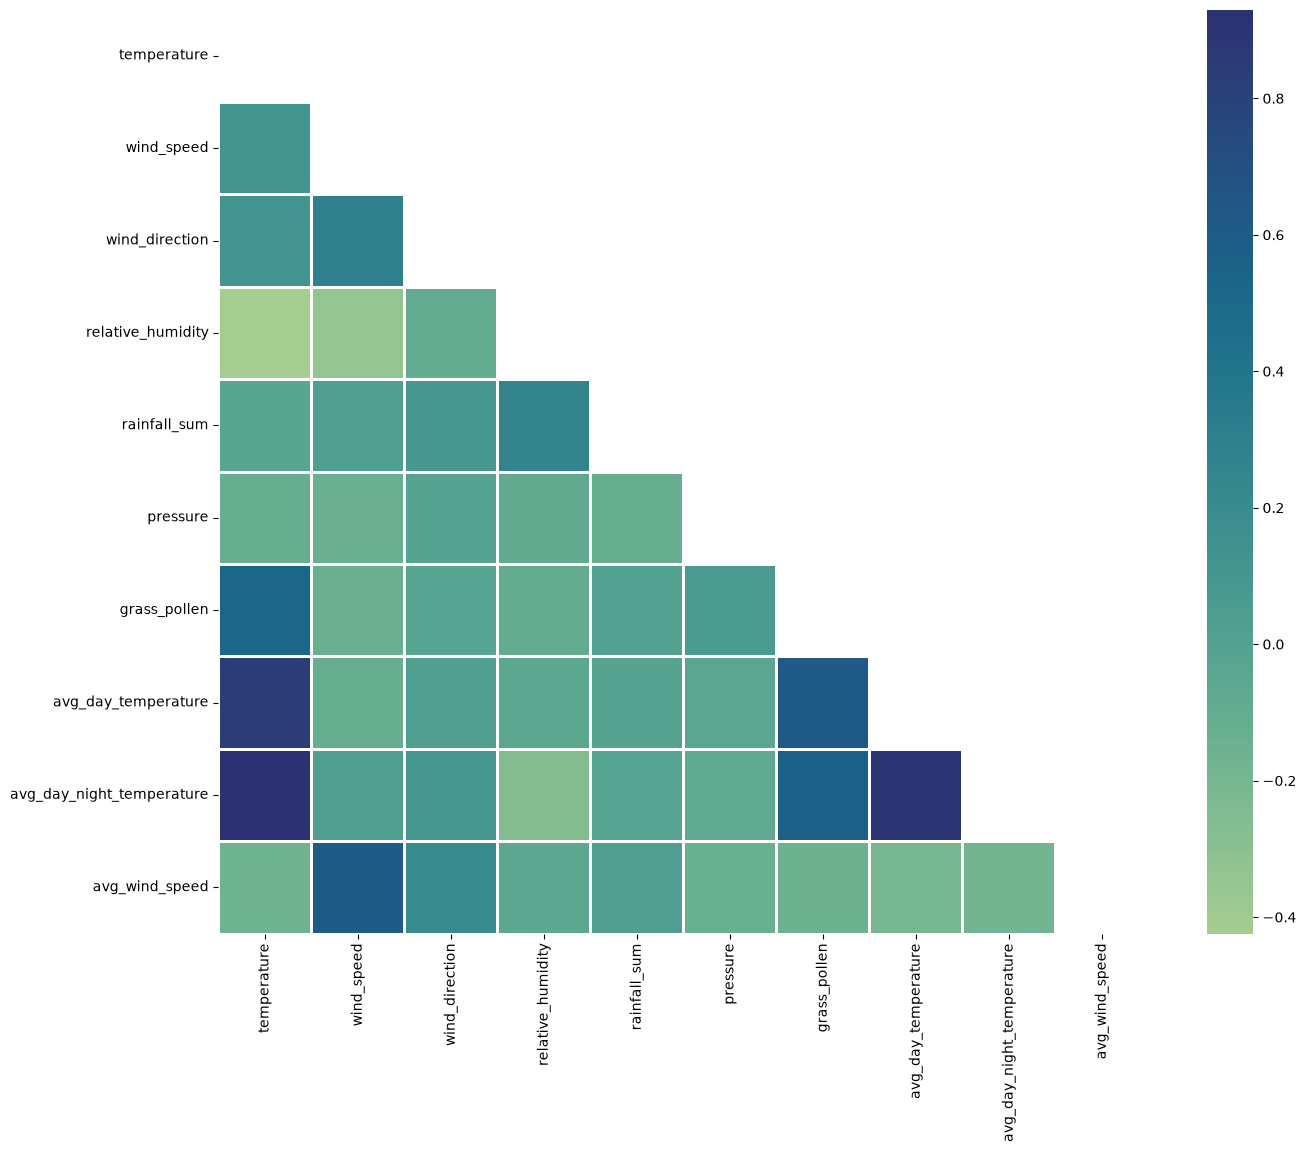

In [24]:
#triangular matrix
num_cols = df_merged_mean_temperature_by_date.select_dtypes(['int', 'float']).columns
corr_data = df_merged_mean_temperature_by_date[num_cols]

corr_coef = corr_data.corr()
plt.figure(figsize=(15, 12))
matrix = np.triu(corr_coef)
sns.heatmap(corr_coef,linewidth=.8, mask = matrix, cmap="crest");

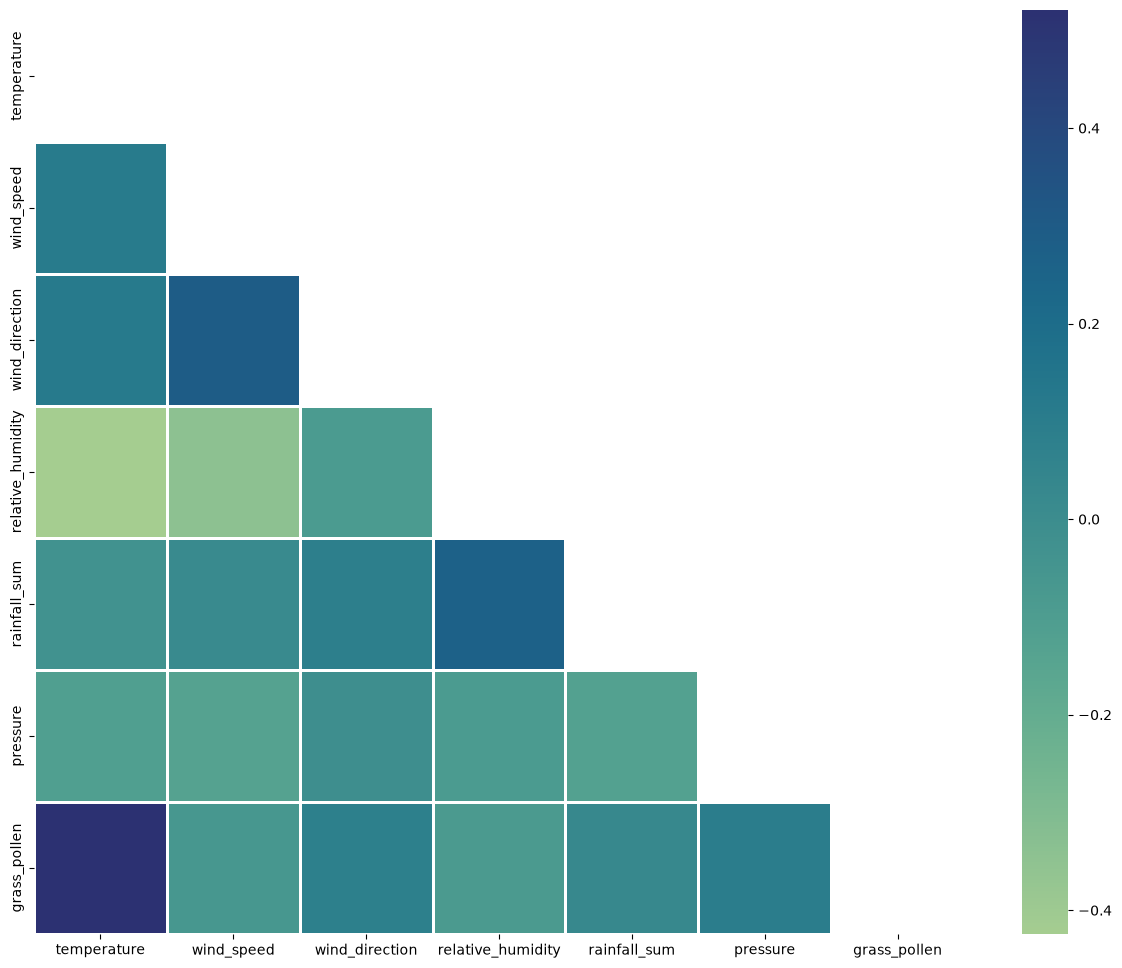

In [25]:
#triangular matrix date ahead
num_cols_date_ahead = df_merged_date_ahead.select_dtypes(['int', 'float']).columns
corr_data = df_merged_date_ahead[num_cols_date_ahead]

corr_coef_date_ahead = corr_data.corr()
plt.figure(figsize=(15, 12))
matrix = np.triu(corr_coef_date_ahead)
sns.heatmap(corr_coef_date_ahead,linewidth=.8, mask = matrix, cmap="crest");

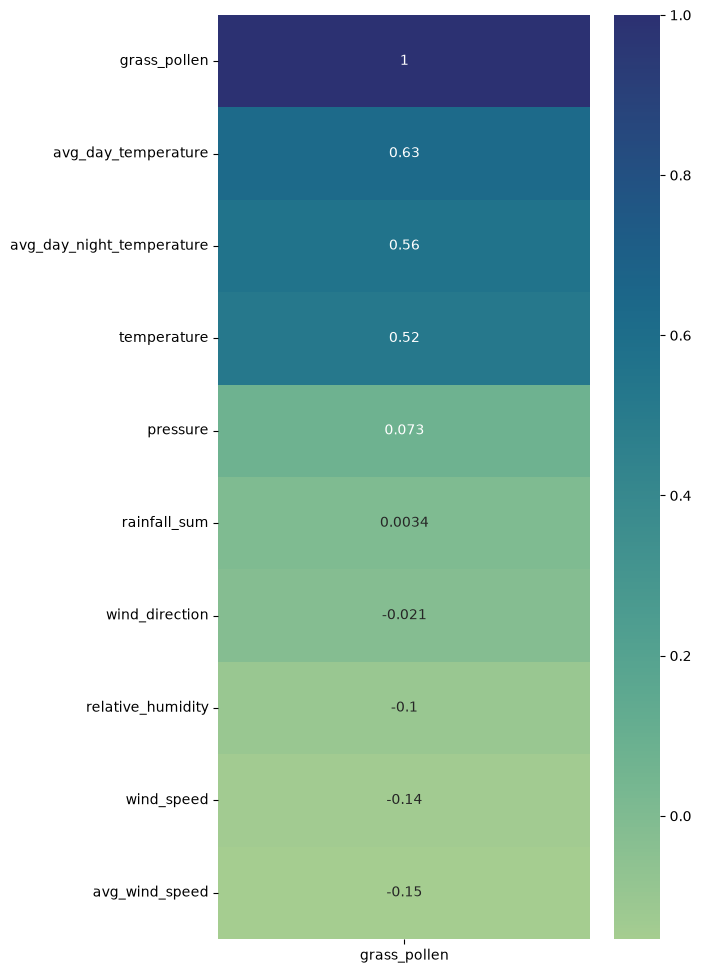

In [26]:
plt.figure(figsize=(6,12))
sns.heatmap(corr_coef[['grass_pollen']].sort_values(by=['grass_pollen'], ascending=False),
            cmap='crest',
            annot=True);

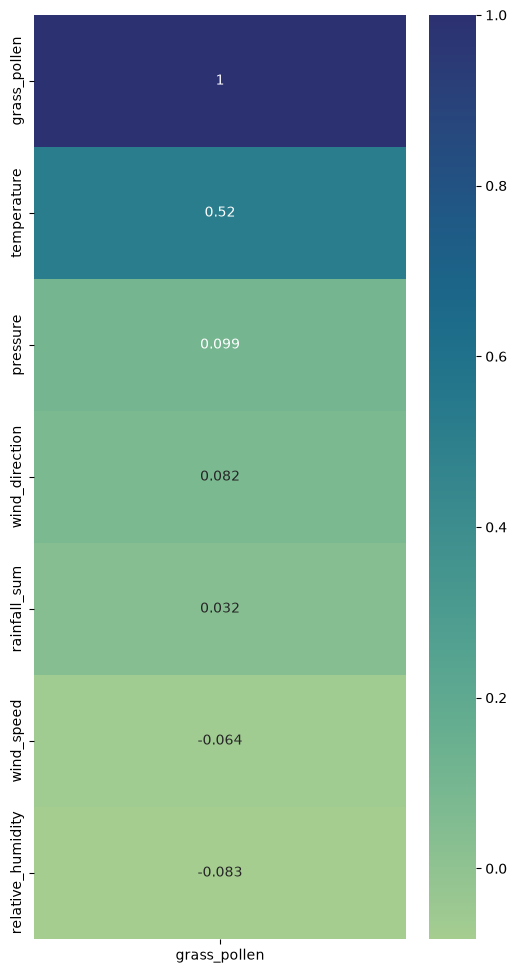

In [27]:
#date ahead
plt.figure(figsize=(6,12))
sns.heatmap(corr_coef_date_ahead[['grass_pollen']].sort_values(by=['grass_pollen'], ascending=False),
            cmap='crest',
            annot=True);


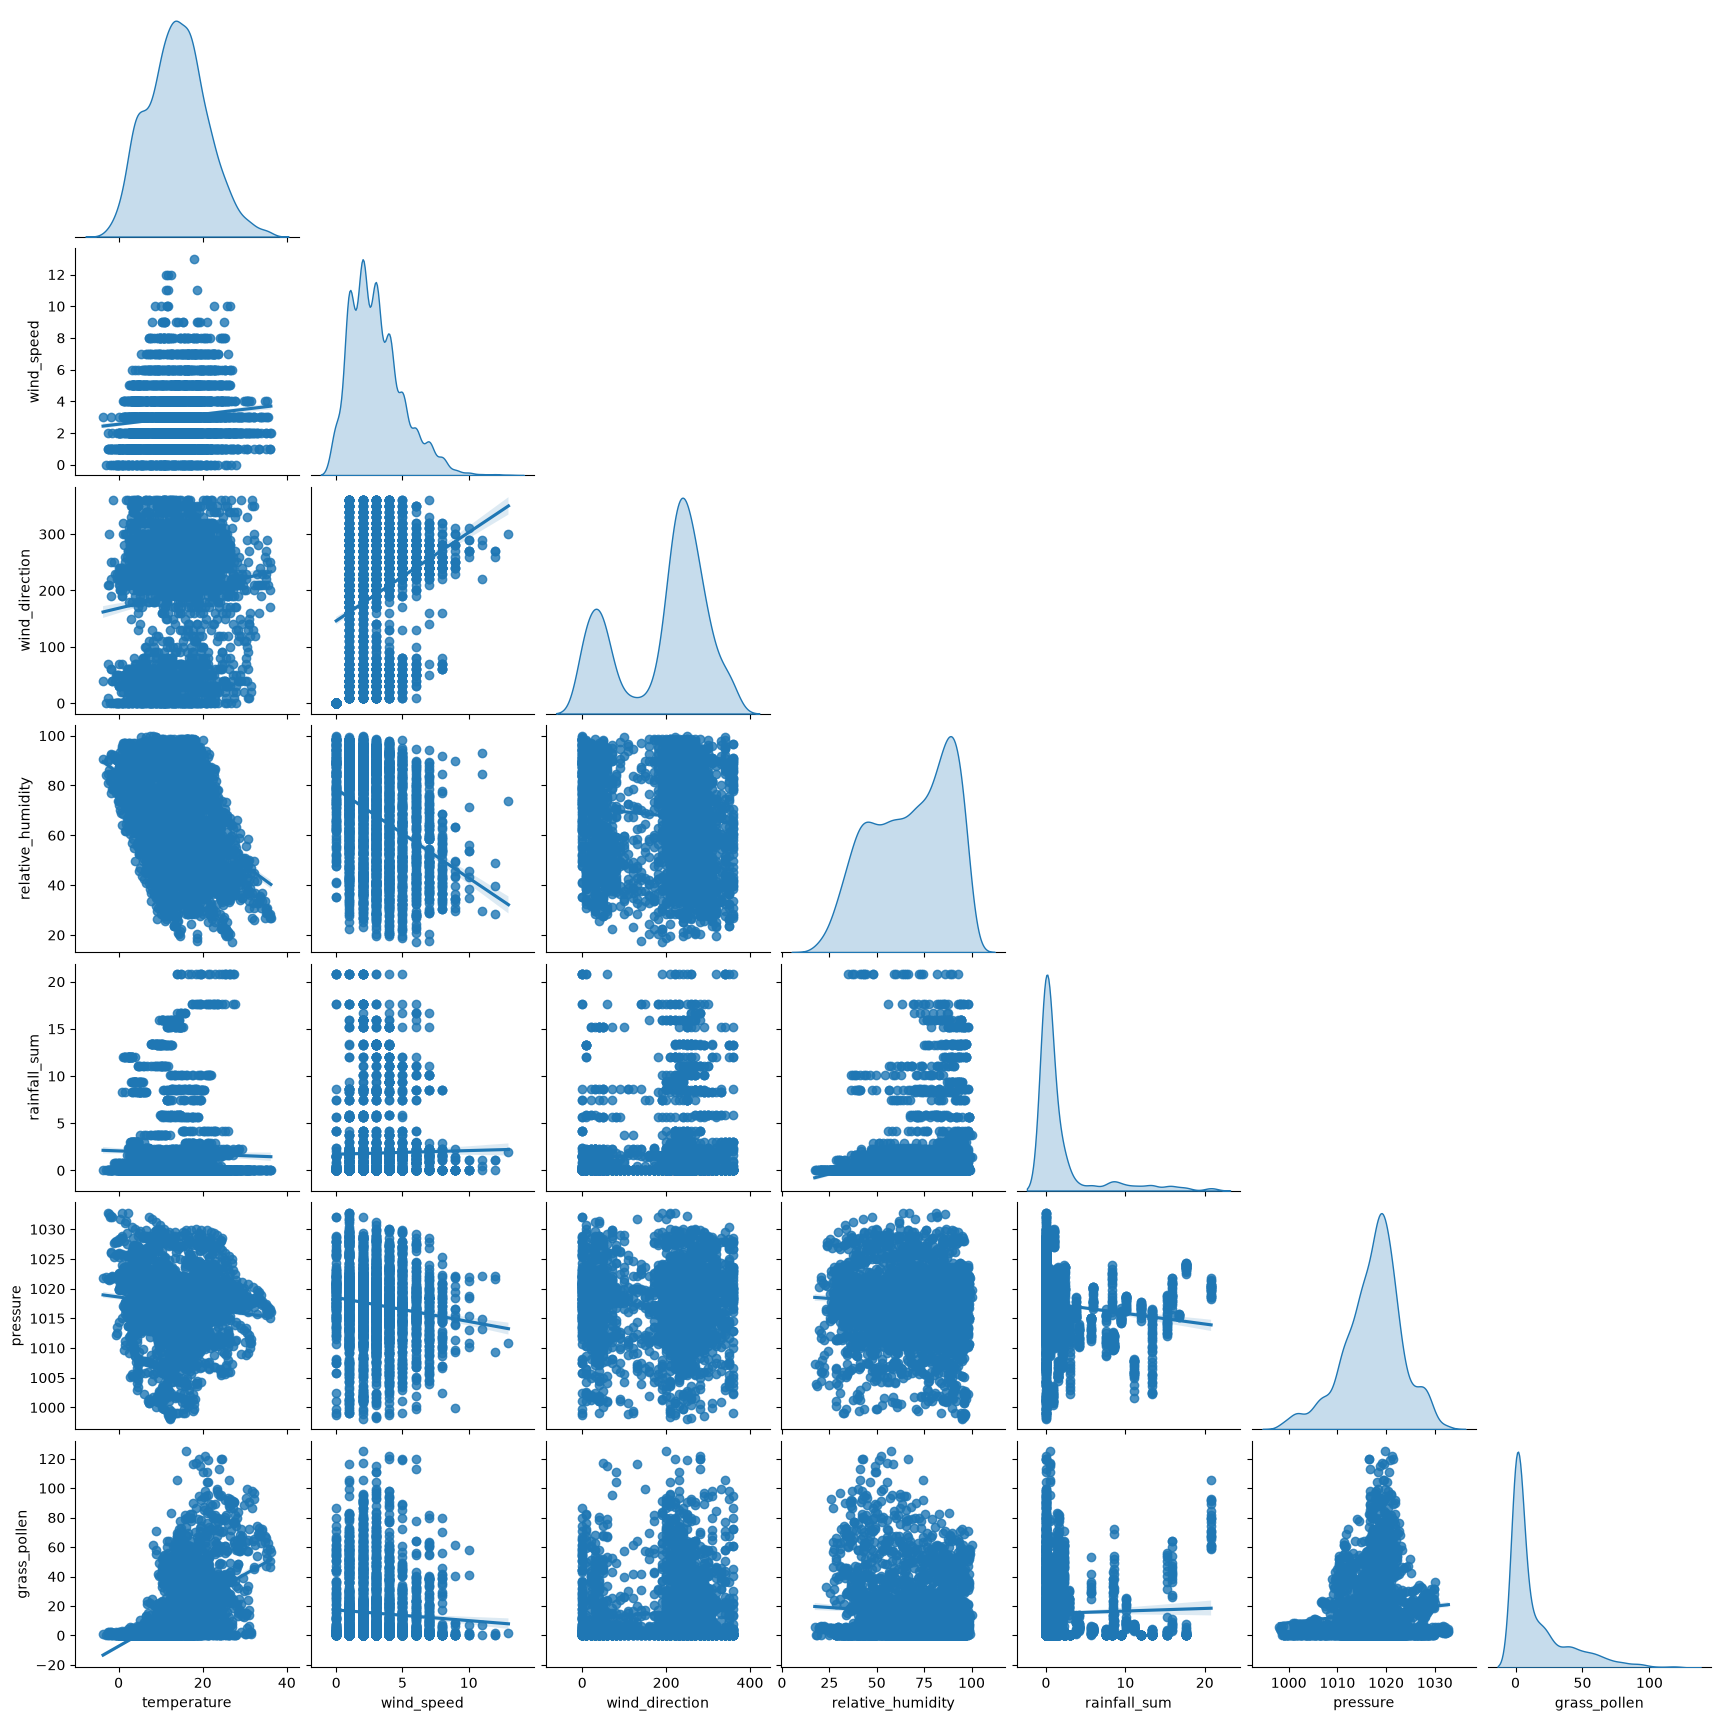

In [28]:
sns.pairplot(corr_data, corner=True, kind='reg', diag_kind='kde')

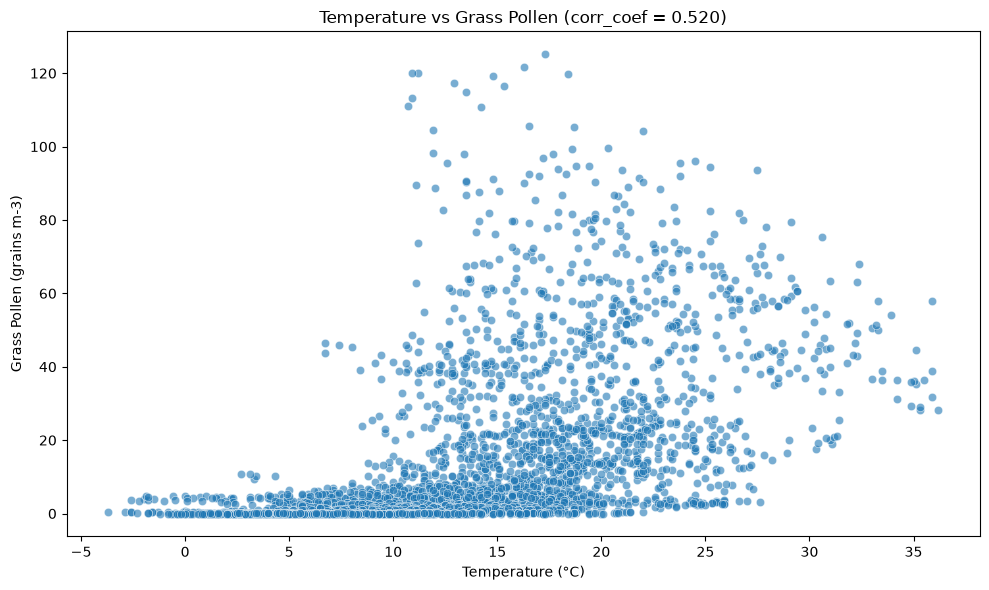

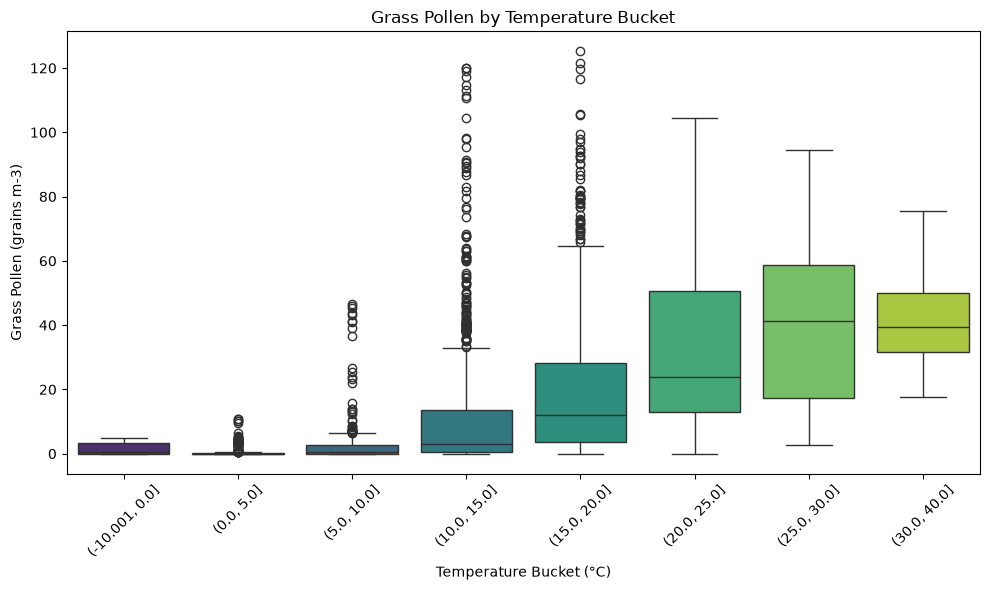

In [29]:
scatter_df = df_merged.dropna(subset=['temperature', 'grass_pollen']).copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_df, x='temperature', y='grass_pollen', alpha=0.6)
#sns.regplot(data=scatter_df, x='temperature', y='grass_pollen', scatter=False, color='black')
plt.title(f'Temperature vs Grass Pollen (corr_coef = {scatter_df[["temperature", "grass_pollen"]].corr().iloc[0, 1]:.3f})')
plt.xlabel('Temperature (°C)')
plt.ylabel('Grass Pollen (grains m-3)')
plt.tight_layout()
plt.show()

bucket_df = df_merged.dropna(subset=['temperature', 'grass_pollen']).copy()
bucket_df['temperature_bucket'] = pd.cut(
    bucket_df['temperature'],
    bins=[-10, 0, 5, 10, 15, 20, 25, 30, 40],
    right=True,
    include_lowest=True
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=bucket_df, x='temperature_bucket', y='grass_pollen', hue='temperature_bucket', dodge=False, legend=False, palette='viridis')
plt.title('Grass Pollen by Temperature Bucket')
plt.xlabel('Temperature Bucket (°C)')
plt.ylabel('Grass Pollen (grains m-3)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

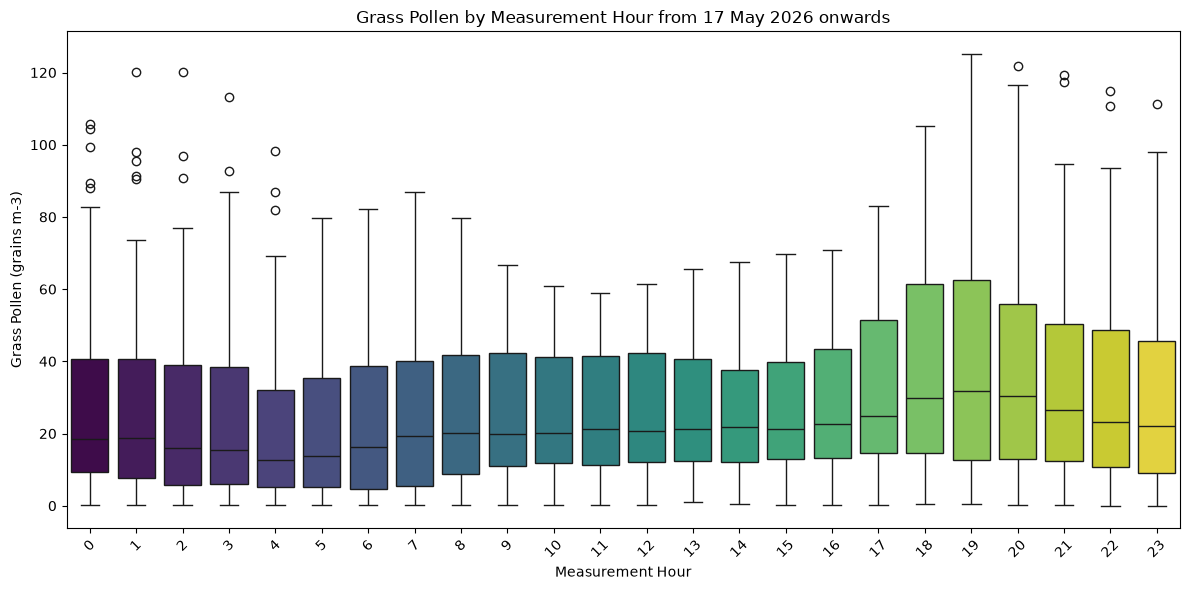

In [30]:
df_merged_from_date = df_merged[df_merged['date'] >= '2026-05-17'].copy()
hourly_df = df_merged_from_date.dropna(subset=['measurement_hour', 'grass_pollen']).copy()
hourly_df['measurement_hour'] = hourly_df['measurement_hour'].apply(lambda h: h.hour)

plt.figure(figsize=(12, 6))
sns.boxplot(data=hourly_df, x='measurement_hour', y='grass_pollen', hue='measurement_hour', dodge=False, legend=False, palette='viridis')
plt.title('Grass Pollen by Measurement Hour from 17 May 2026 onwards')
plt.xlabel('Measurement Hour')
plt.ylabel('Grass Pollen (grains m-3)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
df_merged_from_date_range_1 = df_merged_mean_temperature_by_date[(df_merged_mean_temperature_by_date['date'] >= '2026-05-28') & (df_merged_mean_temperature_by_date['date'] < '2026-06-05')].copy()
plot_df_1 = df_merged_from_date_range_1.sort_values(['date', 'measurement_hour'])
plot_df_1.head(60)

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature,day_night,avg_day_night_temperature,avg_wind_speed
1332,2026-05-28,2026-05-28 12:00:00,00:00:00,2026-05-28 00:00:00,12.300,3.000,310,46.600,0.000,1020.100,2026-05-28,12:00:00,40.535,14.425,night,10.186,3.417
1333,2026-05-28,2026-05-28 13:00:00,01:00:00,2026-05-28 01:00:00,11.700,3.000,310,48.500,0.000,1020.100,2026-05-28,13:00:00,40.131,14.425,night,10.186,3.417
1334,2026-05-28,2026-05-28 14:00:00,02:00:00,2026-05-28 02:00:00,8.400,2.000,270,64.700,0.000,1020.600,2026-05-28,14:00:00,39.185,14.425,night,10.186,3.417
1335,2026-05-28,2026-05-28 15:00:00,03:00:00,2026-05-28 03:00:00,9.400,1.000,230,61.700,0.000,1020.800,2026-05-28,15:00:00,36.672,14.425,night,10.186,3.417
1336,2026-05-28,2026-05-28 16:00:00,04:00:00,2026-05-28 04:00:00,10.400,3.000,260,60.700,0.000,1021.200,2026-05-28,16:00:00,32.948,14.425,night,10.186,3.417
1337,2026-05-28,2026-05-28 17:00:00,05:00:00,2026-05-28 05:00:00,12.200,4.000,290,54.500,0.000,1021.400,2026-05-28,17:00:00,28.696,14.425,day,16.171,3.417
1338,2026-05-28,2026-05-28 18:00:00,06:00:00,2026-05-28 06:00:00,13.400,4.000,280,54.400,0.000,1021.700,2026-05-28,18:00:00,24.191,14.425,day,16.171,3.417
1339,2026-05-28,2026-05-28 19:00:00,07:00:00,2026-05-28 07:00:00,14.300,5.000,270,47.400,0.000,1021.800,2026-05-28,19:00:00,21.653,14.425,day,16.171,3.417
1340,2026-05-28,2026-05-28 20:00:00,08:00:00,2026-05-28 08:00:00,15.600,5.000,290,39.400,0.000,1021.700,2026-05-28,20:00:00,19.689,14.425,day,16.171,3.417
1341,2026-05-28,2026-05-28 21:00:00,09:00:00,2026-05-28 09:00:00,16.700,5.000,300,39.400,0.000,1021.700,2026-05-28,21:00:00,18.272,14.425,day,16.171,3.417


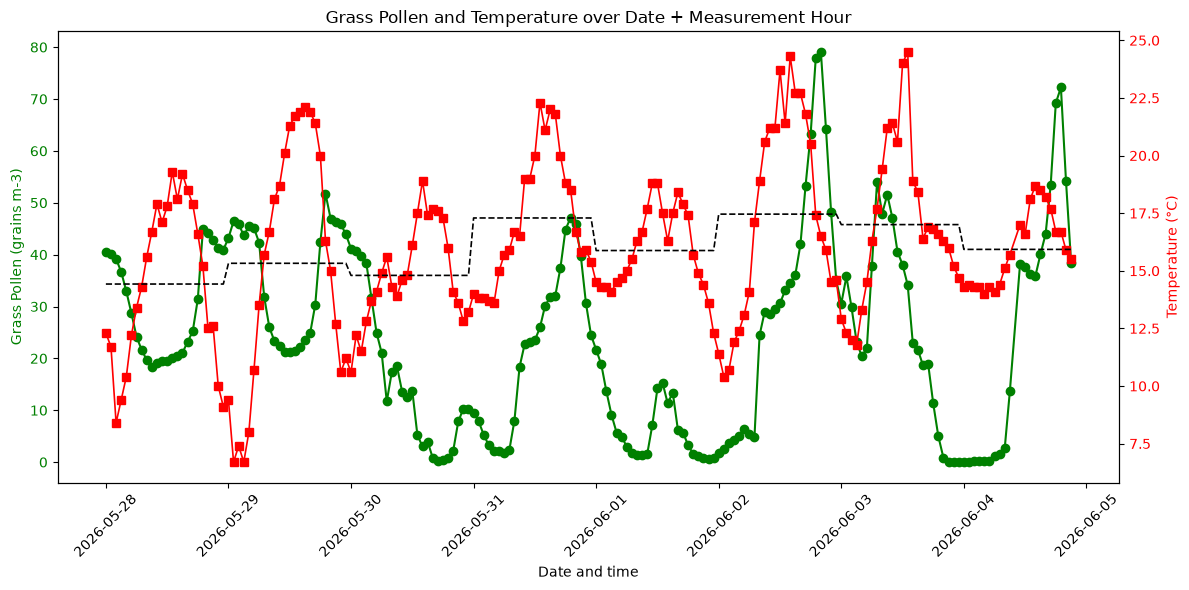

In [32]:
data_1 = plot_df_1['grass_pollen']
data_2 = plot_df_1['temperature']
data_3 = plot_df_1['avg_day_temperature']

x = pd.to_datetime(
    plot_df_1['date'].astype(str)
    + ' '    
    + plot_df_1['measurement_hour'].astype(str)
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x, data_2, color='red', marker='s', linewidth=1.2)
ax2.plot(x, data_3, color='black', linewidth=1.2, linestyle='--', label='Avg Day Temperature')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date + Measurement Hour')
plt.tight_layout()
plt.show()

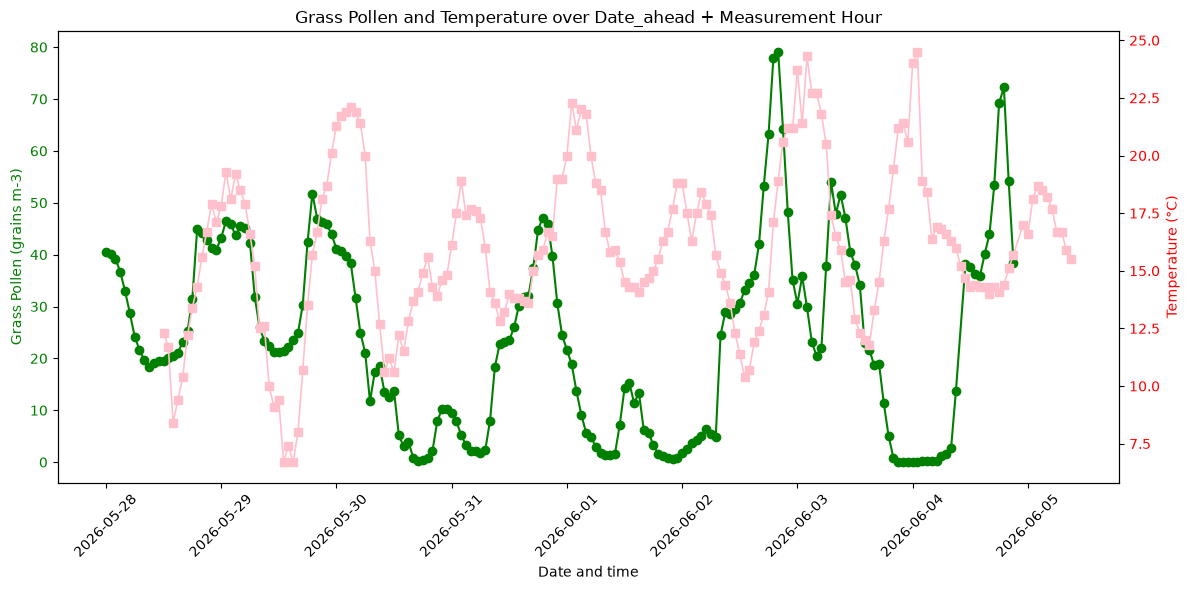

In [33]:
data_1 = plot_df_1['grass_pollen']
data_2 = plot_df_1['temperature']
x = pd.to_datetime(
    plot_df_1['date'].astype(str)
    + ' '    
    + plot_df_1['measurement_hour'].astype(str)
)
x_ahead = plot_df_1['date_N_h_ahead']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x_ahead, data_2, color='pink', marker='s', linewidth=1.2)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date_ahead + Measurement Hour')
plt.tight_layout()
plt.show()

In [34]:
df_merged_from_date_range_2 = df_merged_mean_temperature_by_date[(df_merged_mean_temperature_by_date['date'] >= '2026-07-02') & (df_merged_mean_temperature_by_date['date'] < '2026-07-09')].copy()
plot_df_2 = df_merged_from_date_range_2.sort_values(['date', 'measurement_hour'])
plot_df_2[50:100]

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature,day_night,avg_day_night_temperature,avg_wind_speed
474,2026-07-04,2026-07-05 11:00:00,23:00:00,2026-07-04 23:00:00,12.200,2.000,220,71.700,0.100,1019.200,2026-07-05,11:00:00,45.742,15.800,night,12.850,3.000
445,2026-07-05,2026-07-05 12:00:00,00:00:00,2026-07-05 00:00:00,11.400,2.000,250,76.700,0.100,1019.000,2026-07-05,12:00:00,38.463,15.487,night,12.800,4.375
446,2026-07-05,2026-07-05 13:00:00,01:00:00,2026-07-05 01:00:00,11.200,2.000,250,82.700,0.100,1018.500,2026-07-05,13:00:00,35.792,15.487,night,12.800,4.375
447,2026-07-05,2026-07-05 14:00:00,02:00:00,2026-07-05 02:00:00,12.800,3.000,230,77.900,0.100,1017.900,2026-07-05,14:00:00,33.288,15.487,night,12.800,4.375
448,2026-07-05,2026-07-05 15:00:00,03:00:00,2026-07-05 03:00:00,13.200,3.000,230,79.600,0.100,1017.700,2026-07-05,15:00:00,26.512,15.487,night,12.800,4.375
449,2026-07-05,2026-07-05 16:00:00,04:00:00,2026-07-05 04:00:00,12.600,3.000,220,94.200,0.100,1017.300,2026-07-05,16:00:00,20.931,15.487,night,12.800,4.375
450,2026-07-05,2026-07-05 17:00:00,05:00:00,2026-07-05 05:00:00,13.200,3.000,210,94.200,0.100,1016.900,2026-07-05,17:00:00,18.963,15.487,day,16.594,4.375
451,2026-07-05,2026-07-05 18:00:00,06:00:00,2026-07-05 06:00:00,13.200,4.000,230,94.200,0.900,1016.600,2026-07-05,18:00:00,15.270,15.487,day,16.594,4.375
452,2026-07-05,2026-07-05 19:00:00,07:00:00,2026-07-05 07:00:00,13.600,4.000,220,96.100,0.900,1016.200,2026-07-05,19:00:00,14.845,15.487,day,16.594,4.375
453,2026-07-05,2026-07-05 20:00:00,08:00:00,2026-07-05 08:00:00,16.400,7.000,240,88.900,0.900,1015.600,2026-07-05,20:00:00,15.682,15.487,day,16.594,4.375


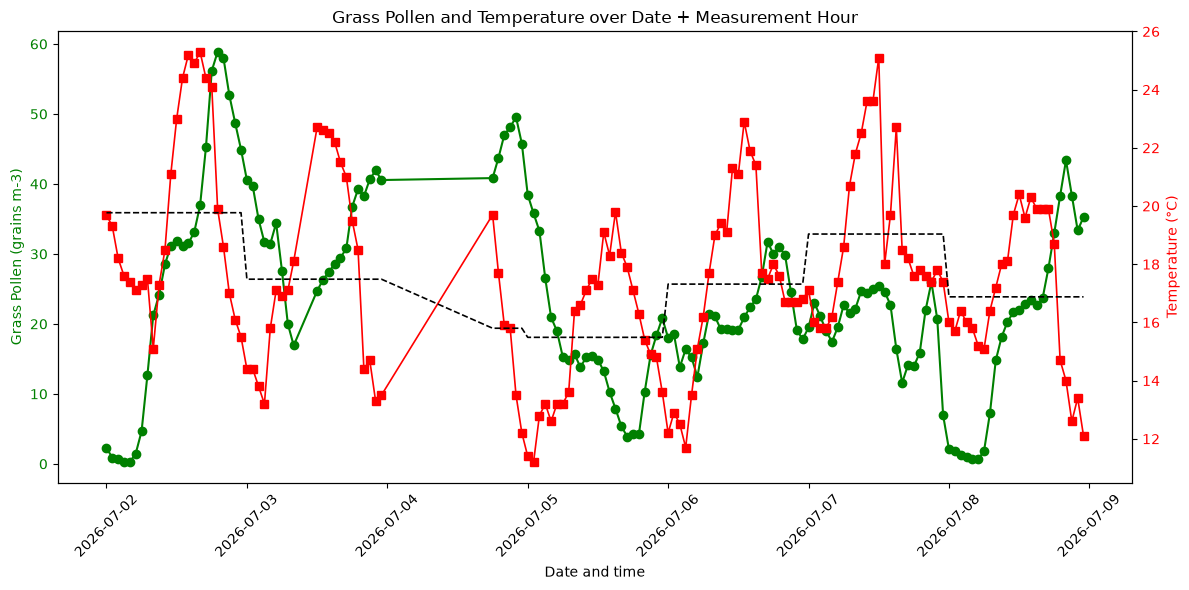

In [35]:
data_1 = plot_df_2['grass_pollen']
data_2 = plot_df_2['temperature']
data_3 = plot_df_2['avg_day_temperature']

x = pd.to_datetime(
    plot_df_2['date'].astype(str)
    + ' '    
    + plot_df_2['measurement_hour'].astype(str)
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x, data_2, color='red', marker='s', linewidth=1.2)
ax2.plot(x, data_3, color='black', linewidth=1.2, linestyle='--', label='Avg Day Temperature')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date + Measurement Hour')
plt.tight_layout()
plt.show()

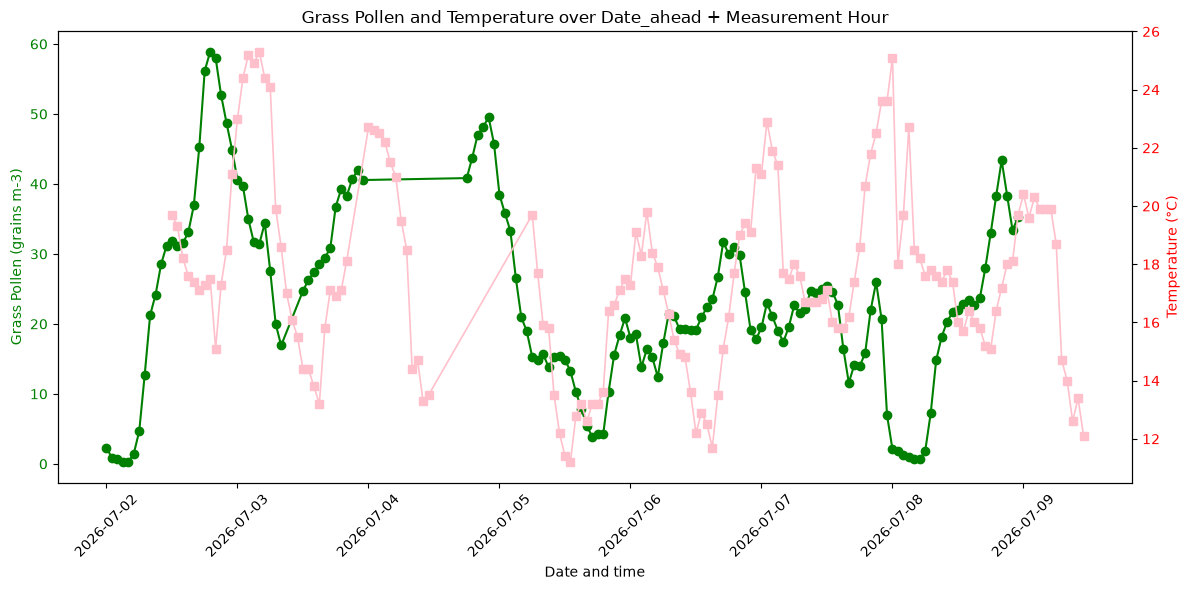

In [36]:
data_1 = plot_df_2['grass_pollen']
data_2 = plot_df_2['temperature']
x = pd.to_datetime(
    plot_df_2['date'].astype(str)
    + ' '    
    + plot_df_2['measurement_hour'].astype(str)
)

x_ahead = plot_df_2['date_N_h_ahead']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x_ahead, data_2, color='pink', marker='s', linewidth=1.2)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date_ahead + Measurement Hour')
plt.tight_layout()
plt.show()

In [37]:
df_merged_from_date_range_3 = df_merged_mean_temperature_by_date[(df_merged_mean_temperature_by_date['date'] >= '2026-06-28') & (df_merged_mean_temperature_by_date['date'] < '2026-07-02')].copy()
plot_df_3 = df_merged_from_date_range_3.sort_values(['date', 'measurement_hour'])
plot_df_3[20:70]

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature,day_night,avg_day_night_temperature,avg_wind_speed
612,2026-06-28,2026-06-29 08:00:00,20:00:00,2026-06-28 20:00:00,26.400,1.000,290,65.000,0.000,1017.800,2026-06-29,08:00:00,63.685,28.458,day,31.424,1.375
613,2026-06-28,2026-06-29 09:00:00,21:00:00,2026-06-28 21:00:00,25.800,0.000,0,68.300,0.000,1018.200,2026-06-29,09:00:00,65.491,28.458,day,31.424,1.375
614,2026-06-28,2026-06-29 10:00:00,22:00:00,2026-06-28 22:00:00,25.300,1.000,40,70.500,0.000,1018.400,2026-06-29,10:00:00,67.530,28.458,night,21.257,1.375
615,2026-06-28,2026-06-29 11:00:00,23:00:00,2026-06-28 23:00:00,23.700,0.000,0,78.300,0.000,1018.300,2026-06-29,11:00:00,71.064,28.458,night,21.257,1.375
568,2026-06-29,2026-06-29 12:00:00,00:00:00,2026-06-29 00:00:00,22.700,0.000,0,83.800,0.000,1018.200,2026-06-29,12:00:00,66.219,28.904,night,22.043,2.292
569,2026-06-29,2026-06-29 13:00:00,01:00:00,2026-06-29 01:00:00,21.400,1.000,20,87.500,0.000,1018.200,2026-06-29,13:00:00,63.154,28.904,night,22.043,2.292
570,2026-06-29,2026-06-29 14:00:00,02:00:00,2026-06-29 02:00:00,20.800,0.000,0,88.600,0.000,1018.200,2026-06-29,14:00:00,62.713,28.904,night,22.043,2.292
571,2026-06-29,2026-06-29 15:00:00,03:00:00,2026-06-29 03:00:00,20.600,0.000,0,88.600,0.000,1018.300,2026-06-29,15:00:00,58.815,28.904,night,22.043,2.292
572,2026-06-29,2026-06-29 16:00:00,04:00:00,2026-06-29 04:00:00,22.200,1.000,270,79.600,0.000,1018.300,2026-06-29,16:00:00,56.225,28.904,night,22.043,2.292
573,2026-06-29,2026-06-29 17:00:00,05:00:00,2026-06-29 05:00:00,26.800,0.000,0,59.900,0.000,1017.900,2026-06-29,17:00:00,50.333,28.904,day,31.729,2.292


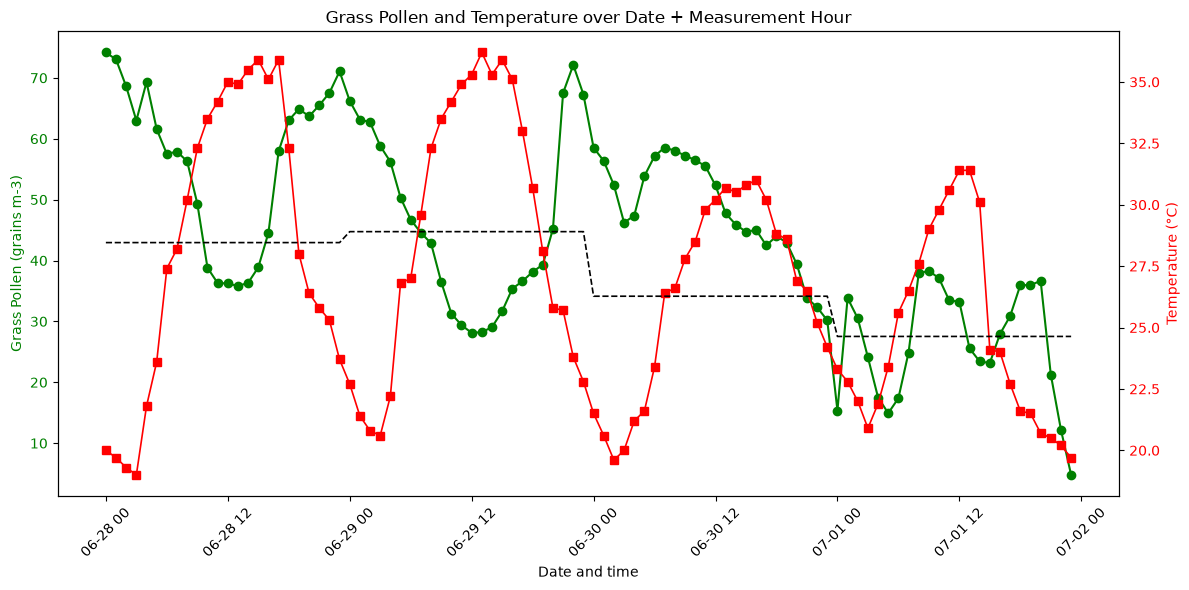

In [38]:
data_1 = plot_df_3['grass_pollen']
data_2 = plot_df_3['temperature']
data_3 = plot_df_3['avg_day_temperature']

x = pd.to_datetime(
    plot_df_3['date'].astype(str)
    + ' '    
    + plot_df_3['measurement_hour'].astype(str)
)

x_ahead = plot_df_3['date_N_h_ahead']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x, data_2, color='red', marker='s', linewidth=1.2)
ax2.plot(x, data_3, color='black', linewidth=1.2, linestyle='--', label='Avg Day Temperature')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date + Measurement Hour')
plt.tight_layout()
plt.show()

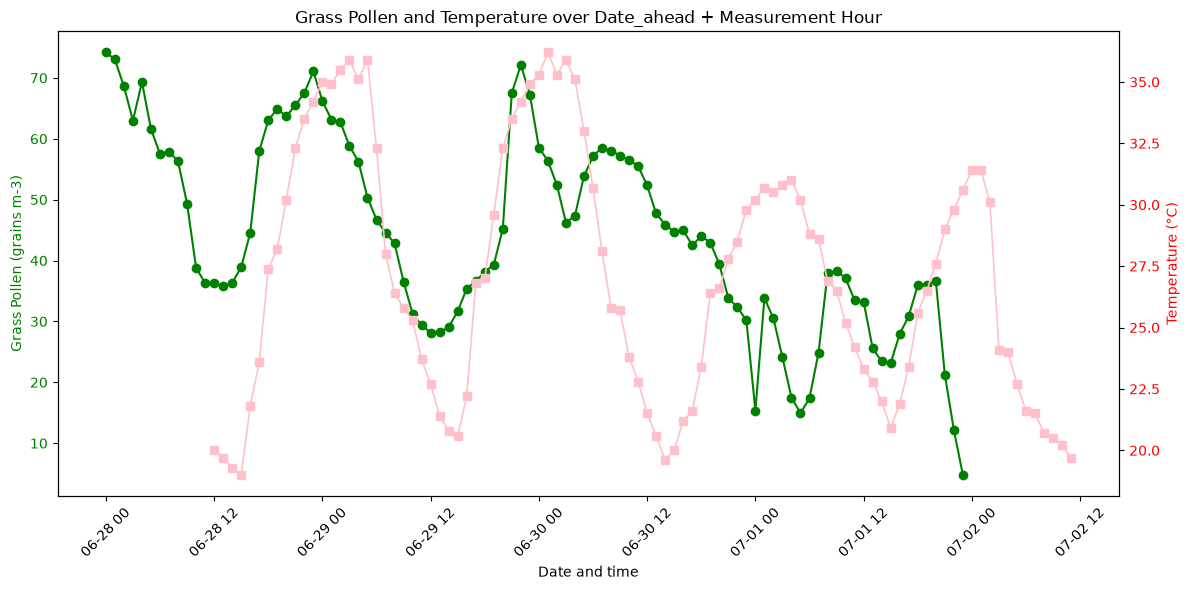

In [39]:
data_1 = plot_df_3['grass_pollen']
data_2 = plot_df_3['temperature']
x = pd.to_datetime(
    plot_df_3['date'].astype(str)
    + ' '    
    + plot_df_3['measurement_hour'].astype(str)
)

x_ahead = plot_df_3['date_N_h_ahead']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x_ahead, data_2, color='pink', marker='s', linewidth=1.2)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date_ahead + Measurement Hour')
plt.tight_layout()
plt.show()

In [40]:
df_merged_from_date_range_June = df_merged_mean_temperature_by_date[(df_merged_mean_temperature_by_date['date'] >= '2026-06-01') & (df_merged_mean_temperature_by_date['date'] < '2026-06-30')].copy()
plot_df_June = df_merged_from_date_range_June.sort_values(['date', 'measurement_hour'])
plot_df_June[470:520]

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature,day_night,avg_day_night_temperature,avg_wind_speed
802,2026-06-20,2026-06-21 06:00:00,18:00:00,2026-06-20 18:00:00,25.700,2.000,30,67.000,2.300,1020.700,2026-06-21,06:00:00,61.432,22.829,day,23.941,2.542
803,2026-06-20,2026-06-21 07:00:00,19:00:00,2026-06-20 19:00:00,24.800,3.000,40,69.500,2.300,1021.000,2026-06-21,07:00:00,70.739,22.829,day,23.941,2.542
804,2026-06-20,2026-06-21 08:00:00,20:00:00,2026-06-20 20:00:00,22.600,3.000,30,77.600,2.300,1021.700,2026-06-21,08:00:00,57.867,22.829,day,23.941,2.542
805,2026-06-20,2026-06-21 09:00:00,21:00:00,2026-06-20 21:00:00,22.800,3.000,20,73.300,2.300,1021.700,2026-06-21,09:00:00,41.372,22.829,day,23.941,2.542
806,2026-06-20,2026-06-21 10:00:00,22:00:00,2026-06-20 22:00:00,21.900,4.000,270,76.600,2.300,1022.600,2026-06-21,10:00:00,27.896,22.829,night,20.129,2.542
807,2026-06-20,2026-06-21 11:00:00,23:00:00,2026-06-20 23:00:00,21.200,2.000,20,80.500,2.300,1022.600,2026-06-21,11:00:00,25.125,22.829,night,20.129,2.542
760,2026-06-21,2026-06-21 12:00:00,00:00:00,2026-06-21 00:00:00,20.100,3.000,240,86.900,2.300,1022.500,2026-06-21,12:00:00,22.776,22.004,night,19.357,2.167
761,2026-06-21,2026-06-21 13:00:00,01:00:00,2026-06-21 01:00:00,18.400,2.000,250,92.000,2.300,1022.700,2026-06-21,13:00:00,18.381,22.004,night,19.357,2.167
762,2026-06-21,2026-06-21 14:00:00,02:00:00,2026-06-21 02:00:00,19.000,1.000,230,93.800,2.300,1022.800,2026-06-21,14:00:00,15.024,22.004,night,19.357,2.167
763,2026-06-21,2026-06-21 15:00:00,03:00:00,2026-06-21 03:00:00,18.900,1.000,220,92.000,2.300,1023.200,2026-06-21,15:00:00,13.319,22.004,night,19.357,2.167


In [41]:
plot_df_June[520:570]

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature,day_night,avg_day_night_temperature,avg_wind_speed
756,2026-06-22,2026-06-23 08:00:00,20:00:00,2026-06-22 20:00:00,18.700,2.000,230,95.600,1.500,1022.500,2026-06-23,08:00:00,5.132,20.033,day,20.924,2.458
757,2026-06-22,2026-06-23 09:00:00,21:00:00,2026-06-22 21:00:00,18.100,0.000,0,98.100,1.500,1022.300,2026-06-23,09:00:00,16.081,20.033,day,20.924,2.458
758,2026-06-22,2026-06-23 10:00:00,22:00:00,2026-06-22 22:00:00,17.300,1.000,220,98.700,1.500,1022.200,2026-06-23,10:00:00,31.107,20.033,night,17.871,2.458
759,2026-06-22,2026-06-23 11:00:00,23:00:00,2026-06-22 23:00:00,17.100,2.000,250,98.100,1.500,1022.200,2026-06-23,11:00:00,46.660,20.033,night,17.871,2.458
712,2026-06-23,2026-06-23 12:00:00,00:00:00,2026-06-23 00:00:00,16.300,1.000,250,98.100,1.500,1021.900,2026-06-23,12:00:00,60.509,21.425,night,16.286,1.667
713,2026-06-23,2026-06-23 13:00:00,01:00:00,2026-06-23 01:00:00,15.100,2.000,240,98.700,1.500,1021.700,2026-06-23,13:00:00,69.391,21.425,night,16.286,1.667
714,2026-06-23,2026-06-23 14:00:00,02:00:00,2026-06-23 02:00:00,14.900,1.000,170,98.700,1.500,1021.700,2026-06-23,14:00:00,76.283,21.425,night,16.286,1.667
715,2026-06-23,2026-06-23 15:00:00,03:00:00,2026-06-23 03:00:00,14.300,0.000,0,98.700,1.500,1022.100,2026-06-23,15:00:00,68.375,21.425,night,16.286,1.667
716,2026-06-23,2026-06-23 16:00:00,04:00:00,2026-06-23 04:00:00,15.400,0.000,0,91.800,1.500,1022.100,2026-06-23,16:00:00,60.945,21.425,night,16.286,1.667
717,2026-06-23,2026-06-23 17:00:00,05:00:00,2026-06-23 05:00:00,17.000,1.000,230,82.700,1.500,1021.900,2026-06-23,17:00:00,53.740,21.425,day,23.541,1.667


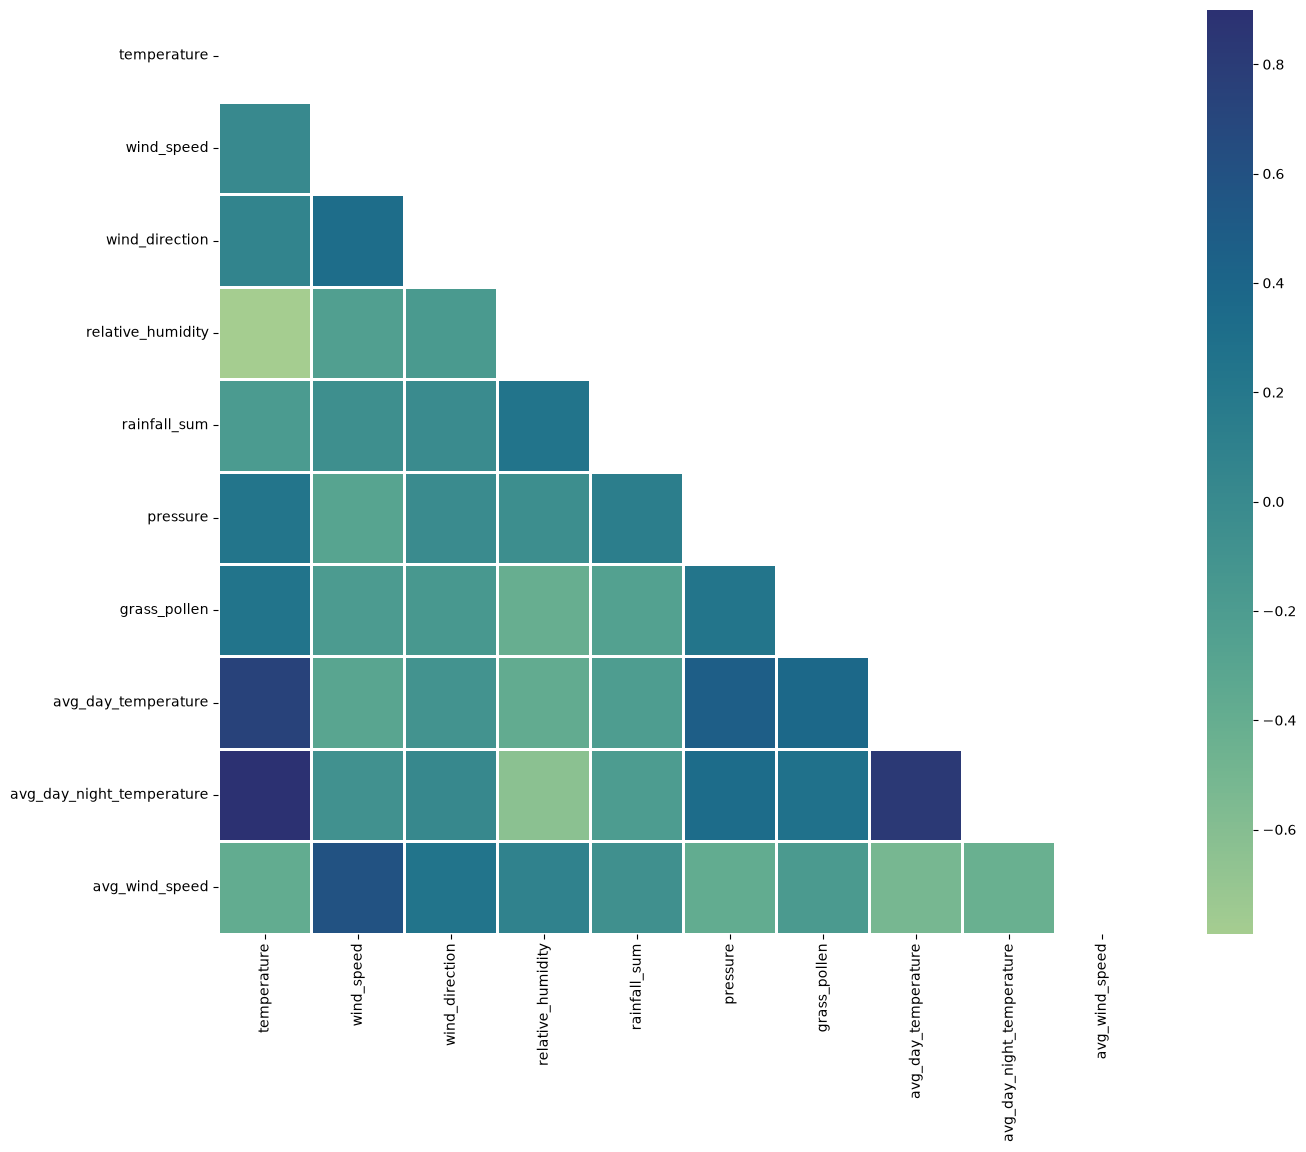

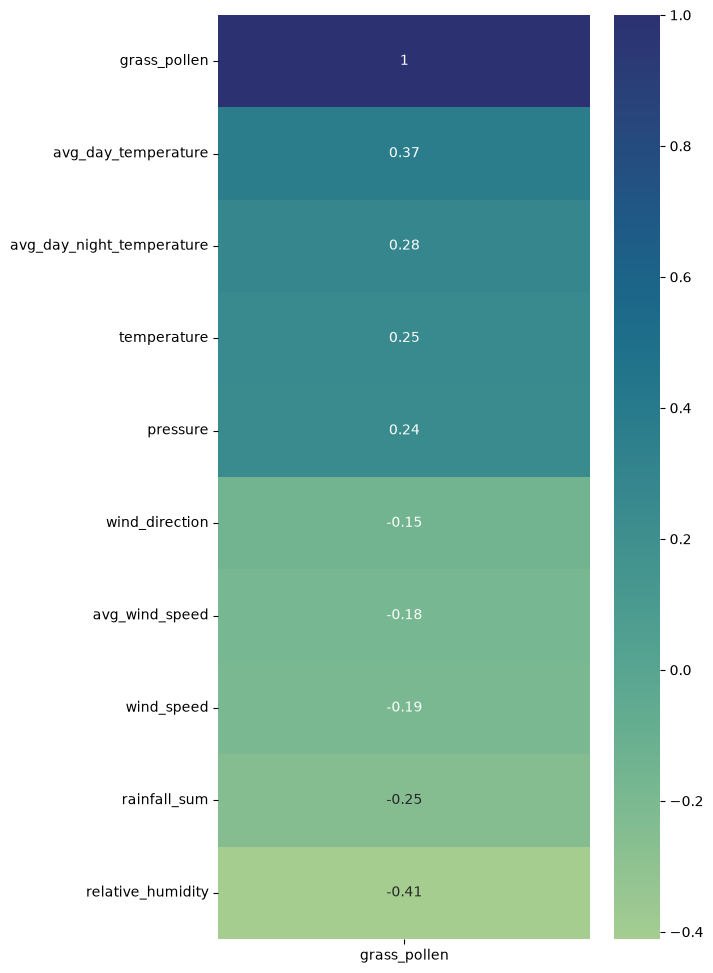

In [42]:
#corr July 2026
#triangular matrix
num_cols_day_night_temperature = plot_df_June.select_dtypes(['int', 'float']).columns
corr_data_day_night_temperature = plot_df_June[num_cols_day_night_temperature]

corr_coef_day_night_temperature = corr_data_day_night_temperature.corr()
plt.figure(figsize=(15, 12))
matrix = np.triu(corr_coef_day_night_temperature)
sns.heatmap(corr_coef_day_night_temperature,linewidth=.8, mask = matrix, cmap="crest")

plt.figure(figsize=(6,12))
sns.heatmap(corr_coef_day_night_temperature[['grass_pollen']].sort_values(by=['grass_pollen'], ascending=False),
            cmap='crest',
            annot=True);

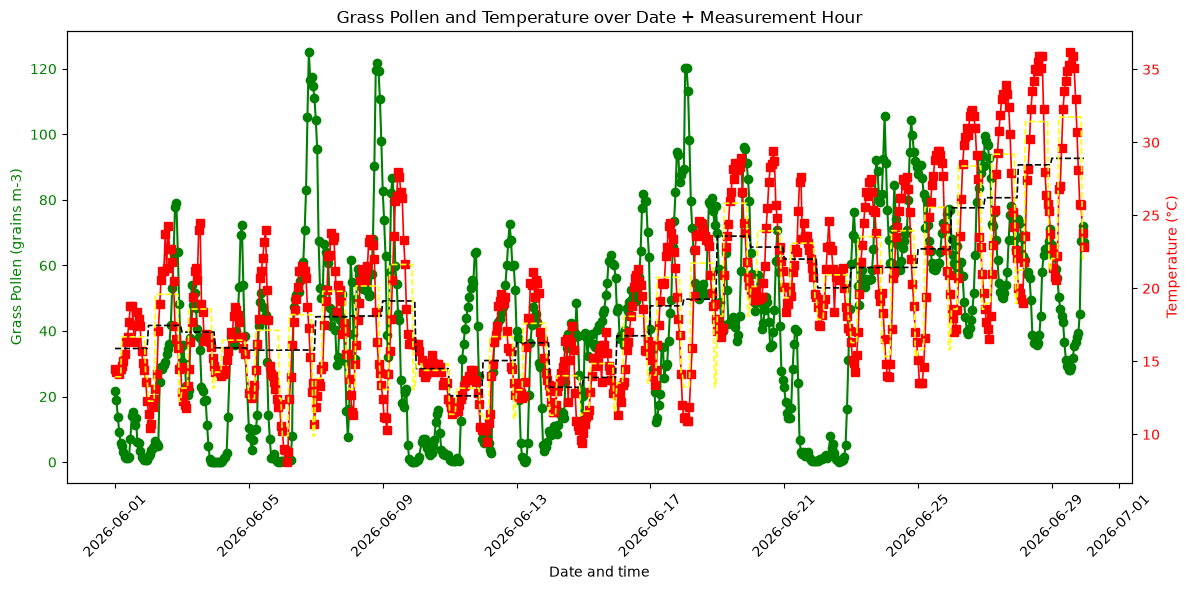

In [43]:
data_1 = plot_df_June['grass_pollen']
data_2 = plot_df_June['temperature']
data_3 = plot_df_June['avg_day_temperature']
data_4 = plot_df_June['avg_day_night_temperature']

x = pd.to_datetime(
    plot_df_June['date'].astype(str)
    + ' '    
    + plot_df_June['measurement_hour'].astype(str)
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x, data_2, color='red', marker='s', linewidth=1.2)
ax2.plot(x, data_3, color='black', linewidth=1.2, linestyle='--', label='Avg Day Temperature')
ax2.plot(x, data_4, color='yellow', linewidth=1.2, linestyle='--', label='Avg Day Night Temperature')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date + Measurement Hour')
plt.tight_layout()
plt.show()

In [44]:
#rainfall vs grass pollen 20.06.2026 - 25.06.2026
df_merged_from_date_range_rainfall = df_merged_mean_temperature_by_date[(df_merged_mean_temperature_by_date['date'] >= '2026-06-20') & (df_merged_mean_temperature_by_date['date'] < '2026-06-25')].copy()
plot_df_rainfall = df_merged_from_date_range_rainfall.sort_values(['date', 'measurement_hour'])
plot_df_rainfall[0:50] 

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature,day_night,avg_day_night_temperature,avg_wind_speed
784,2026-06-20,2026-06-20 12:00:00,00:00:00,2026-06-20 00:00:00,19.900,2.000,30,84.700,0.000,1020.300,2026-06-20,12:00:00,63.915,22.829,night,20.129,2.542
785,2026-06-20,2026-06-20 13:00:00,01:00:00,2026-06-20 01:00:00,19.600,3.000,20,84.600,0.000,1020.300,2026-06-20,13:00:00,57.478,22.829,night,20.129,2.542
786,2026-06-20,2026-06-20 14:00:00,02:00:00,2026-06-20 02:00:00,19.200,3.000,30,86.800,0.000,1020.400,2026-06-20,14:00:00,48.829,22.829,night,20.129,2.542
787,2026-06-20,2026-06-20 15:00:00,03:00:00,2026-06-20 03:00:00,19.200,2.000,20,86.800,0.000,1020.500,2026-06-20,15:00:00,46.159,22.829,night,20.129,2.542
788,2026-06-20,2026-06-20 16:00:00,04:00:00,2026-06-20 04:00:00,19.900,2.000,30,82.500,0.000,1021.100,2026-06-20,16:00:00,48.827,22.829,night,20.129,2.542
789,2026-06-20,2026-06-20 17:00:00,05:00:00,2026-06-20 05:00:00,19.300,1.000,190,92.600,0.000,1021.700,2026-06-20,17:00:00,57.047,22.829,day,23.941,2.542
790,2026-06-20,2026-06-20 18:00:00,06:00:00,2026-06-20 06:00:00,19.300,3.000,200,95.600,2.300,1021.800,2026-06-20,18:00:00,49.027,22.829,day,23.941,2.542
791,2026-06-20,2026-06-20 19:00:00,07:00:00,2026-06-20 07:00:00,19.400,1.000,10,93.800,2.300,1022.600,2026-06-20,19:00:00,48.630,22.829,day,23.941,2.542
792,2026-06-20,2026-06-20 20:00:00,08:00:00,2026-06-20 08:00:00,19.400,4.000,30,93.800,2.300,1023.200,2026-06-20,20:00:00,40.456,22.829,day,23.941,2.542
793,2026-06-20,2026-06-20 21:00:00,09:00:00,2026-06-20 09:00:00,20.400,3.000,140,87.500,2.300,1022.700,2026-06-20,21:00:00,42.383,22.829,day,23.941,2.542


In [45]:
plot_df_rainfall.tail(50)

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature,day_night,avg_day_night_temperature,avg_wind_speed
758,2026-06-22,2026-06-23 10:00:00,22:00:00,2026-06-22 22:00:00,17.300,1.000,220,98.700,1.500,1022.200,2026-06-23,10:00:00,31.107,20.033,night,17.871,2.458
759,2026-06-22,2026-06-23 11:00:00,23:00:00,2026-06-22 23:00:00,17.100,2.000,250,98.100,1.500,1022.200,2026-06-23,11:00:00,46.660,20.033,night,17.871,2.458
712,2026-06-23,2026-06-23 12:00:00,00:00:00,2026-06-23 00:00:00,16.300,1.000,250,98.100,1.500,1021.900,2026-06-23,12:00:00,60.509,21.425,night,16.286,1.667
713,2026-06-23,2026-06-23 13:00:00,01:00:00,2026-06-23 01:00:00,15.100,2.000,240,98.700,1.500,1021.700,2026-06-23,13:00:00,69.391,21.425,night,16.286,1.667
714,2026-06-23,2026-06-23 14:00:00,02:00:00,2026-06-23 02:00:00,14.900,1.000,170,98.700,1.500,1021.700,2026-06-23,14:00:00,76.283,21.425,night,16.286,1.667
715,2026-06-23,2026-06-23 15:00:00,03:00:00,2026-06-23 03:00:00,14.300,0.000,0,98.700,1.500,1022.100,2026-06-23,15:00:00,68.375,21.425,night,16.286,1.667
716,2026-06-23,2026-06-23 16:00:00,04:00:00,2026-06-23 04:00:00,15.400,0.000,0,91.800,1.500,1022.100,2026-06-23,16:00:00,60.945,21.425,night,16.286,1.667
717,2026-06-23,2026-06-23 17:00:00,05:00:00,2026-06-23 05:00:00,17.000,1.000,230,82.700,1.500,1021.900,2026-06-23,17:00:00,53.740,21.425,day,23.541,1.667
718,2026-06-23,2026-06-23 18:00:00,06:00:00,2026-06-23 06:00:00,19.600,2.000,210,74.300,20.800,1021.800,2026-06-23,18:00:00,48.009,21.425,day,23.541,1.667
719,2026-06-23,2026-06-23 19:00:00,07:00:00,2026-06-23 07:00:00,21.800,2.000,220,63.400,20.800,1021.500,2026-06-23,19:00:00,56.509,21.425,day,23.541,1.667


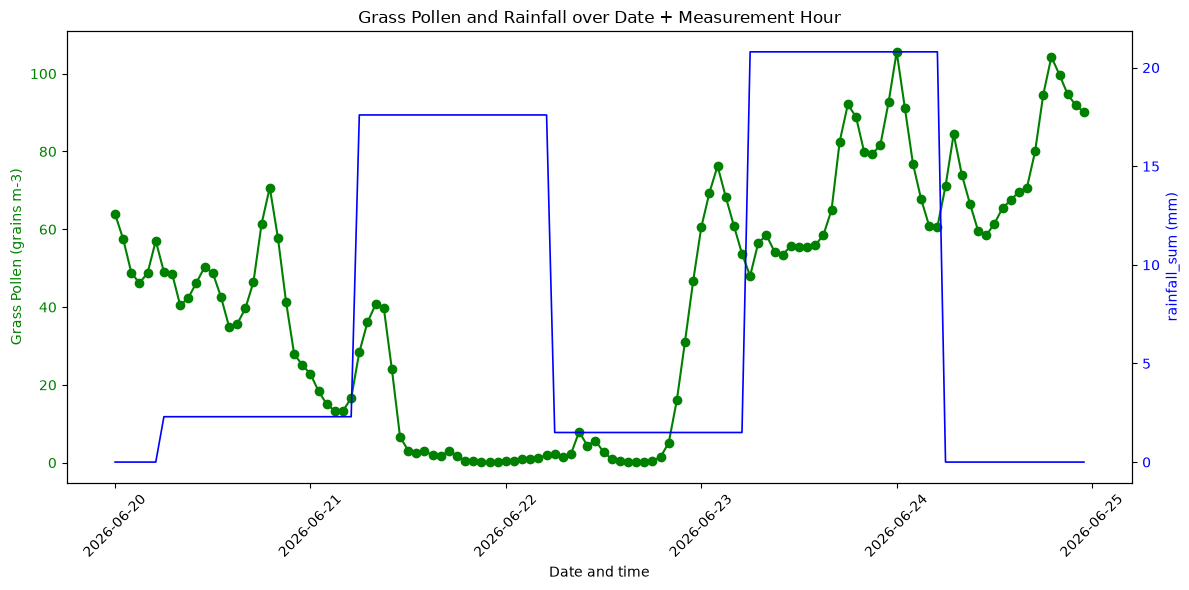

In [46]:
data_1 = plot_df_rainfall['grass_pollen']
data_2 = plot_df_rainfall['rainfall_sum']


x = pd.to_datetime(
    plot_df_rainfall['date'].astype(str)
    + ' '    
    + plot_df_rainfall['measurement_hour'].astype(str)
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('rainfall_sum (mm)', color='blue')
ax2.plot(x, data_2, color='blue', linewidth=1.2)

ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Grass Pollen and Rainfall over Date + Measurement Hour')
plt.tight_layout()
plt.show()

<Axes: >

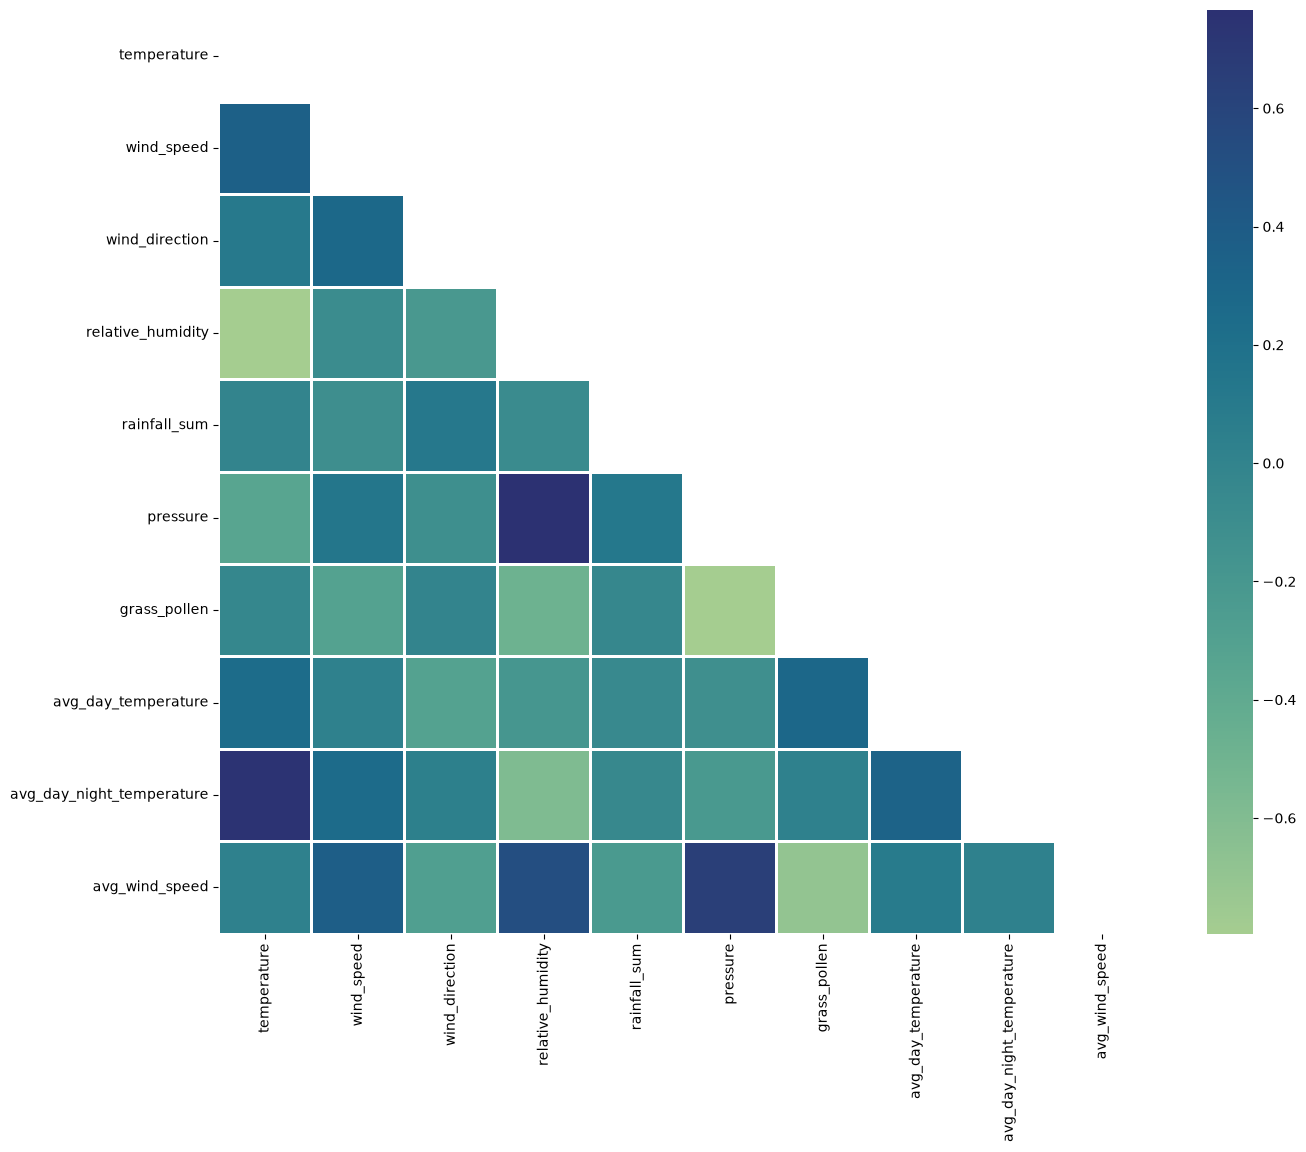

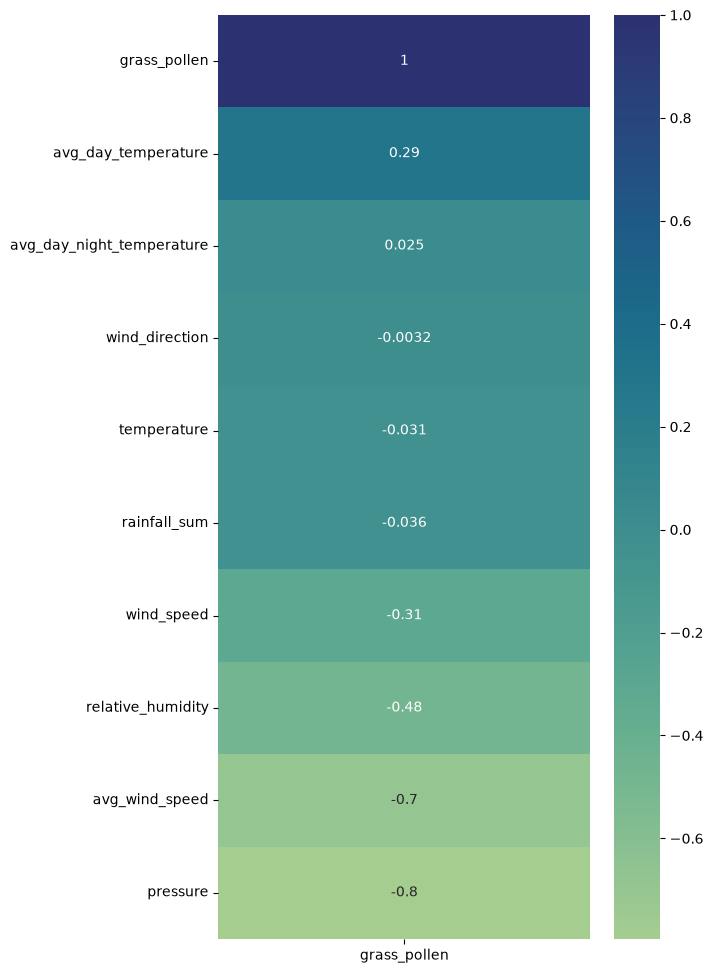

In [47]:
#corr rainfall vs grass pollen 20.06.2026 - 25.06.2026
#triangular matrix
num_cols_rainfall = plot_df_rainfall.select_dtypes(['int', 'float']).columns
corr_data_rainfall = plot_df_rainfall[num_cols_rainfall]

corr_coef_rainfall = corr_data_rainfall.corr()
plt.figure(figsize=(15, 12))
matrix = np.triu(corr_coef_rainfall)
sns.heatmap(corr_coef_rainfall,linewidth=.8, mask = matrix, cmap="crest")

plt.figure(figsize=(6,12))
sns.heatmap(corr_coef_rainfall[['grass_pollen']].sort_values(by=['grass_pollen'], ascending=False),
            cmap='crest',
            annot=True)

<Axes: >

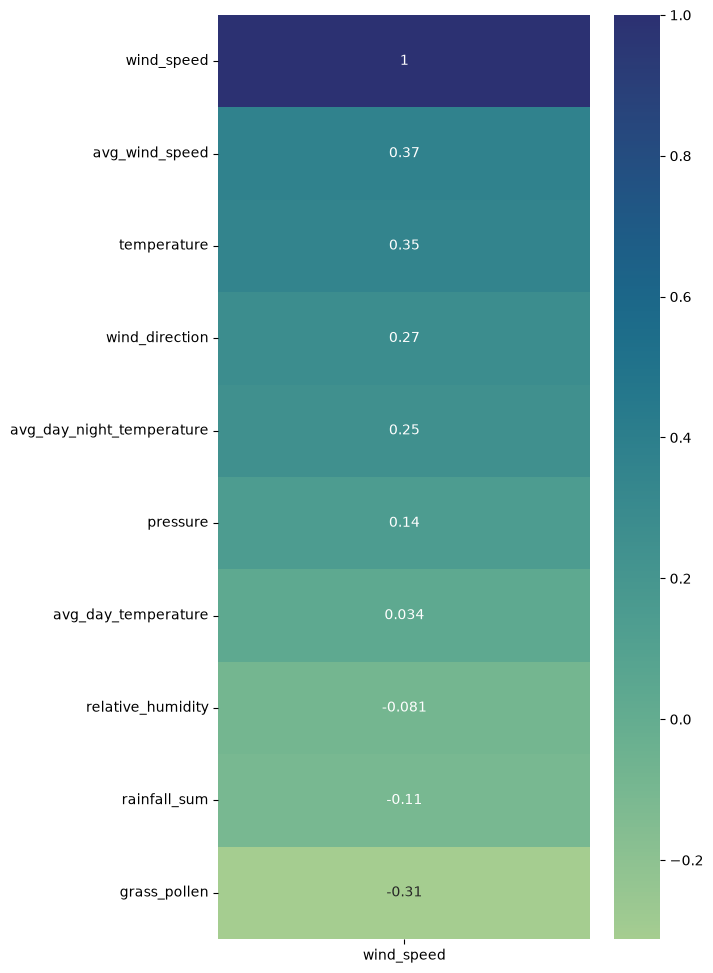

In [48]:
plt.figure(figsize=(6,12))
sns.heatmap(corr_coef_rainfall[['wind_speed']].sort_values(by=['wind_speed'], ascending=False),
            cmap='crest',
            annot=True)

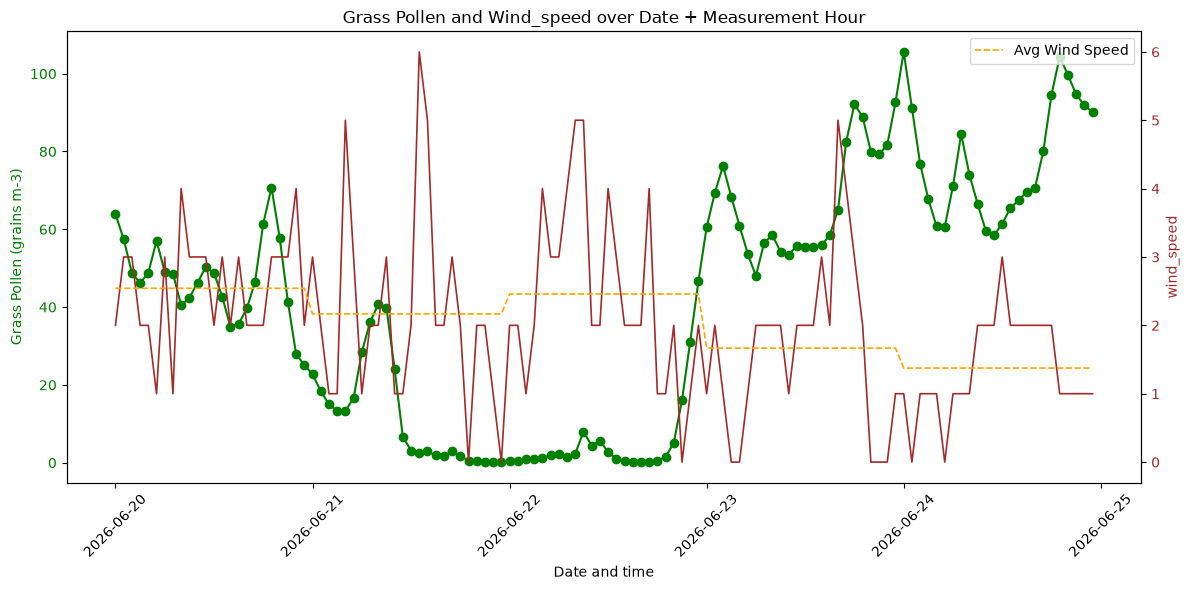

In [49]:
#wind_speed vs grass pollen 20.06.2026 - 25.06.2026
data_1 = plot_df_rainfall['grass_pollen']
data_2 = plot_df_rainfall['wind_speed']
data_3 = plot_df_rainfall['avg_wind_speed']

x = pd.to_datetime(
    plot_df_rainfall['date'].astype(str)
    + ' '    
    + plot_df_rainfall['measurement_hour'].astype(str)
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('wind_speed', color='brown')
ax2.plot(x, data_2, color='brown', linewidth=1.2)
ax2.plot(x, data_3, color='orange', linewidth=1.2, linestyle='--', label='Avg Wind Speed')

ax2.tick_params(axis='y', labelcolor='brown')

plt.title('Grass Pollen and Wind_speed over Date + Measurement Hour')
plt.legend()
plt.tight_layout()
plt.show()

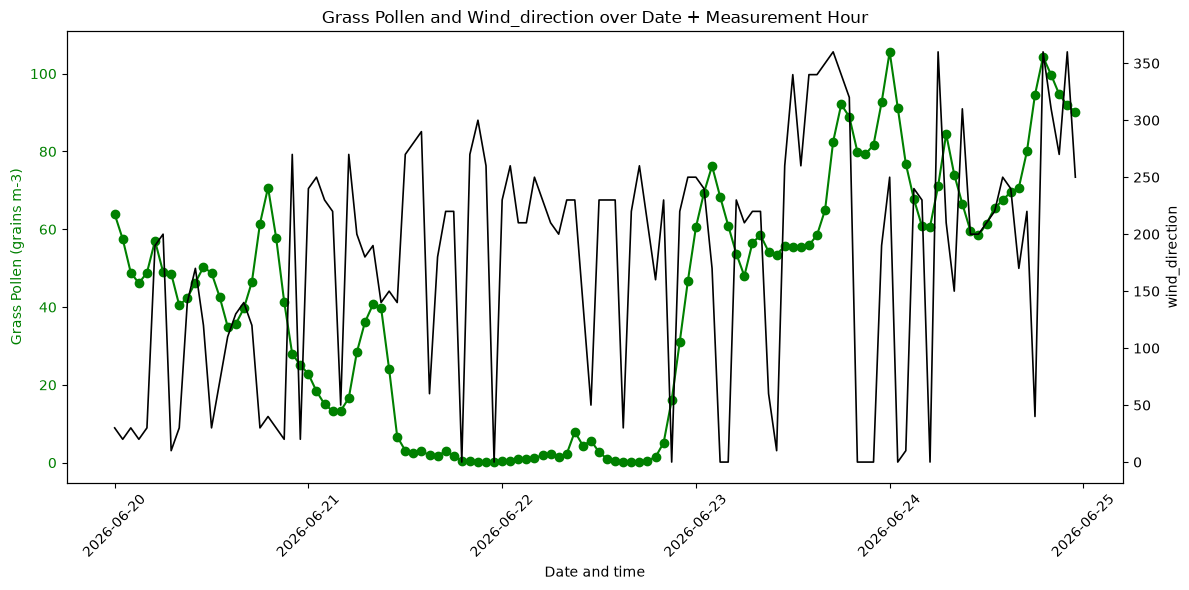

In [50]:
#wind_direction vs grass pollen 20.06.2026 - 25.06.2026
data_1 = plot_df_rainfall['grass_pollen']
data_2 = plot_df_rainfall['wind_direction']

x = pd.to_datetime(
    plot_df_rainfall['date'].astype(str)
    + ' '    
    + plot_df_rainfall['measurement_hour'].astype(str)
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('wind_direction', color='black')
ax2.plot(x, data_2, color='black', linewidth=1.2)

ax2.tick_params(axis='y', labelcolor='black')

plt.title('Grass Pollen and Wind_direction over Date + Measurement Hour')
plt.tight_layout()
plt.show()

In [ ]:
# Prepare predictor matrix and target variable all cols
feature_cols_all = [col for col in ['wind_speed', 'rainfall_sum', 'wind_direction', 'temperature', 'relative_humidity', 'pressure'] if col in plot_df_rainfall.columns]

X_all = plot_df_rainfall[feature_cols_all].copy()
y = plot_df_rainfall['grass_pollen']

X_all.head()

,wind_speed,rainfall_sum,wind_direction,temperature,relative_humidity,pressure
784,2.000,0.000,30,19.900,84.700,1020.300
785,3.000,0.000,20,19.600,84.600,1020.300
786,3.000,0.000,30,19.200,86.800,1020.400
787,2.000,0.000,20,19.200,86.800,1020.500
788,2.000,0.000,30,19.900,82.500,1021.100


In [77]:
scaler_6f = StandardScaler()
scaler_6f.fit(X_all)
pca_data_scaled_6f = scaler_6f.transform(X_all)

In [93]:
pca = PCA(n_components=6)
pca.fit(pca_data_scaled_6f)
pca_wind_rain_6f = pca.transform(pca_data_scaled_6f)

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols_all,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)
loadings


,PC1,PC2,PC3,PC4,PC5,PC6
wind_speed,-0.170,0.740,-0.269,-0.177,0.563,-0.057
rainfall_sum,0.009,0.054,0.888,-0.369,0.250,0.098
wind_direction,-0.215,0.470,0.348,0.727,-0.281,0.063
temperature,-0.543,0.148,-0.101,-0.442,-0.496,0.482
relative_humidity,0.627,0.157,-0.081,0.074,0.043,0.754
pressure,0.486,0.427,0.035,-0.321,-0.542,-0.427


In [94]:
eigenvalues = pca.explained_variance_
prop_var = eigenvalues / np.sum(eigenvalues)

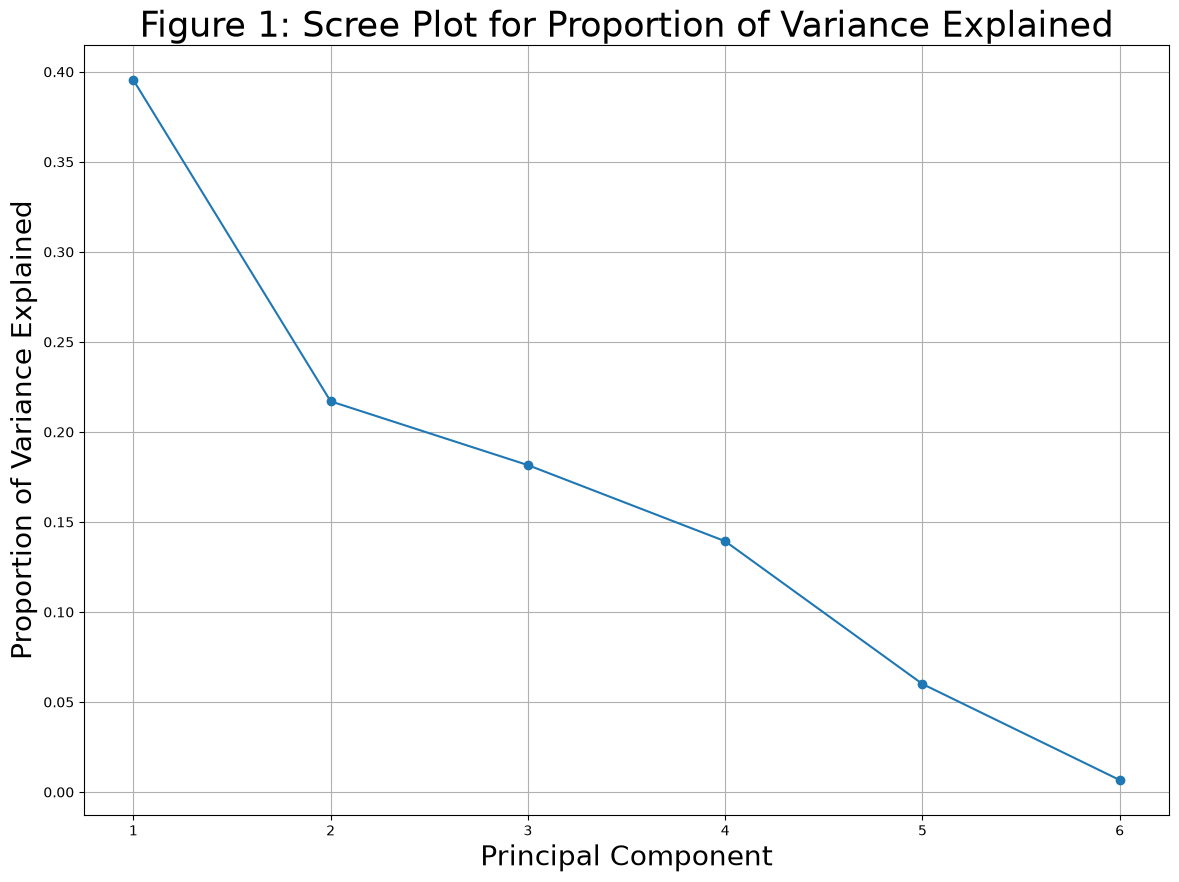

In [95]:
plt.figure(figsize=(14,10))
plt.plot(np.arange(1, len(prop_var)+1), 
                   prop_var, marker='o')
plt.xlabel('Principal Component',
           size = 20)
plt.ylabel('Proportion of Variance Explained',
           size = 20)
plt.title('Figure 1: Scree Plot for Proportion of Variance Explained',
          size = 25)
plt.grid(True)

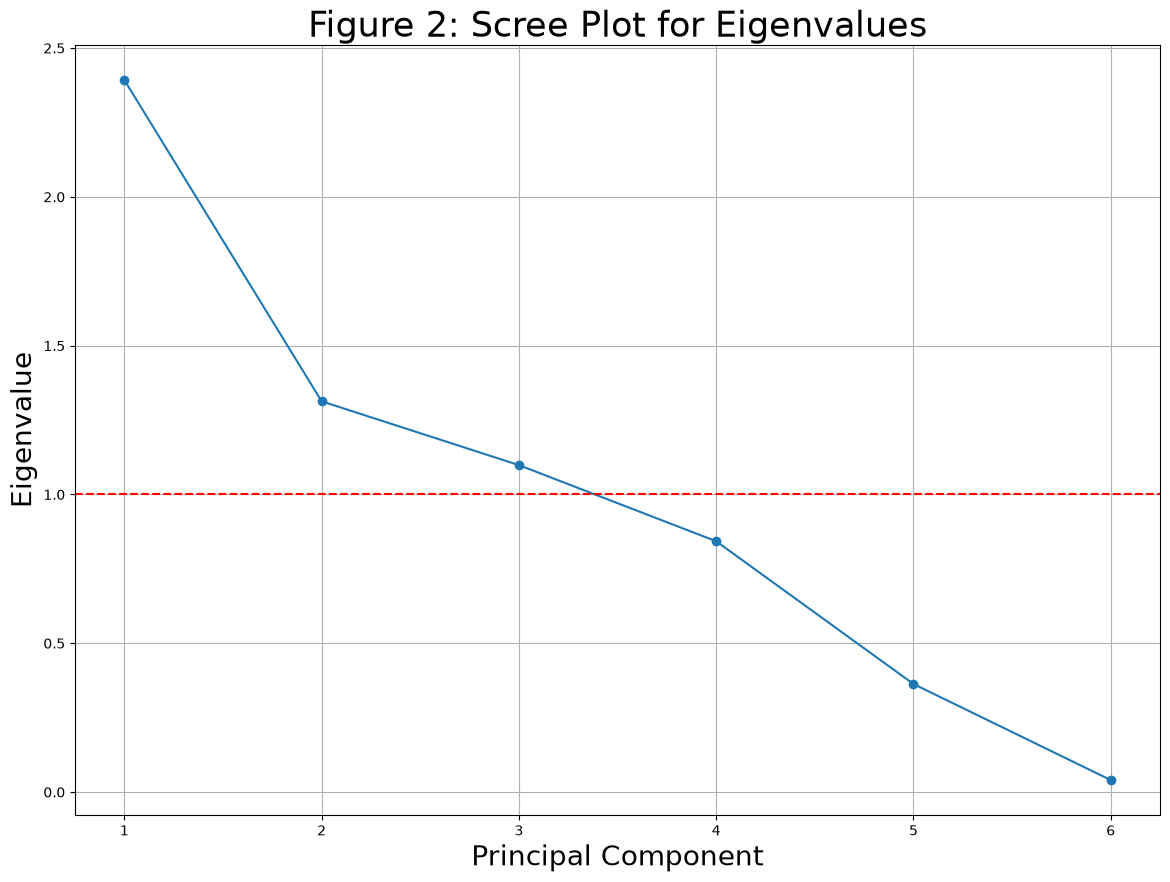

In [96]:
plt.figure(figsize=(14,10))
plt.plot(np.arange(1, len(eigenvalues)+1), 
         eigenvalues, marker='o')
plt.xlabel('Principal Component',
           size = 20)
plt.ylabel('Eigenvalue',
           size = 20)
plt.title('Figure 2: Scree Plot for Eigenvalues',
          size = 25)
plt.axhline(y=1, color='r', 
            linestyle='--')
plt.grid(True)

Principal component analysis was performed on the standardized predictor matrix. The first three principal components were retained because their eigenvalues were greater than 1 and they captured the largest proportion of explained variance, as shown by the scree plot.


In [97]:
pca = PCA(n_components=3)
pca.fit(pca_data_scaled_6f)
pca_wind_rain_6f = pca.transform(pca_data_scaled_6f)

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols_all,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)
loadings

,PC1,PC2,PC3
wind_speed,-0.170,0.740,-0.269
rainfall_sum,0.009,0.054,0.888
wind_direction,-0.215,0.470,0.348
temperature,-0.543,0.148,-0.101
relative_humidity,0.627,0.157,-0.081
pressure,0.486,0.427,0.035


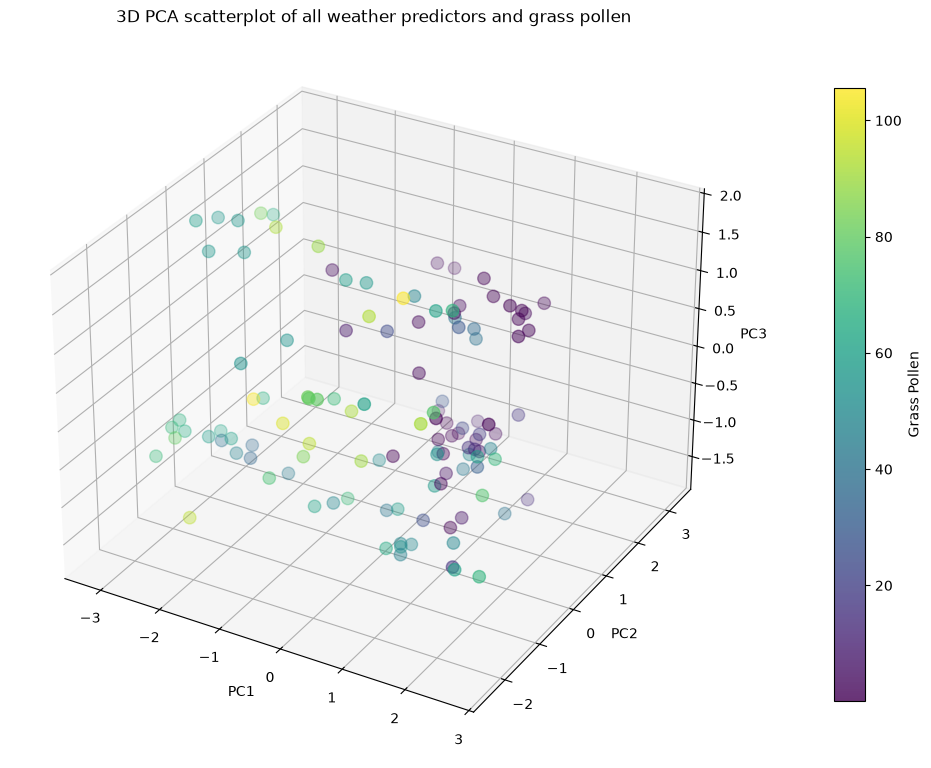

In [98]:
# 3D Scatterplot
Xax = pca_wind_rain_6f[:,0]
Yax = pca_wind_rain_6f[:,1]
Zax = pca_wind_rain_6f[:,2]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    Xax,
    Yax,
    Zax,
    c=y,
    cmap='viridis',
    s=80,
    alpha=0.8
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA scatterplot of all weather predictors and grass pollen')
fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.8).set_label('Grass Pollen')
plt.tight_layout()
plt.show()